# Phase 1 - Business Understanding

SDG 11 – Sustainable Cities & Communities

Problem:
Emergency units do not know:

  - What type of incidents will occur
  - Where incidents frequently happen
  - When incident volume will increase

This causes slow response time and poor resource allocation.

Goal:
  - Use predictive analytics to support smarter emergency planning.

# Phase 2 - Data Understanding

2.1 Import Libraries

In [103]:
# ═══════════════════════════════════════════════════════════════════
# TODO: Import all required libraries — fill in any that are missing
# ═══════════════════════════════════════════════════════════════════

# ── Core ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization ────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ── Statistical Tests ────────────────────────────────────────────────
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
from scipy.stats import boxcox, normaltest, shapiro

# ── Forecasting Models ───────────────────────────────────────────────
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
# Optional — install first: pip install pmdarima
# from pmdarima import auto_arima
# Optional — install first: pip install prophet
# from prophet import Prophet

# ── Classification Models ────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# ── Clustering Models ────────────────────────────────────────────────
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# ── Preprocessing & Model Selection ──────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

# ── Evaluation Metrics ───────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, silhouette_score, davies_bouldin_score

# ── Iteration tools ──────────────────────────────────────────────────
import itertools
import warnings
warnings.filterwarnings('ignore')

# ── Global Plot Settings ─────────────────────────────────────────────
plt.rcParams['figure.figsize']  = (14, 5)
plt.rcParams['axes.grid']       = True
plt.rcParams['grid.alpha']      = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid', palette='muted')

print("✅ All libraries loaded.")

✅ All libraries loaded.


In [104]:
# Install pmdarima for auto_arima
!pip install pmdarima
import pmdarima as pm

2.2 Load Dataset

In [105]:
# For Google Colab: '/content/your_file.csv'
# For local:        'data/your_file.csv'

df = pd.read_csv('/content/Emergency_Response_Incidents.csv')          # TODO: insert file path

print(f"Dataset shape: {df.shape}")
print(f"Columns      : {df.columns.tolist()}")
display(df.head(5))
display(df.tail(5))

Dataset shape: (11750, 7)
Columns      : ['Incident Type', 'Location', 'Borough', 'Creation Date', 'Closed Date', 'Latitude', 'Longitude']


,Incident Type,Location,Borough,Creation Date,Closed Date,Latitude,Longitude
0,Utility-Water Main,136-17 72 Avenue,Queens,01/16/2017 01:13:38 PM,NaN,40.714004,-73.829989
1,Structural-Sidewalk Collapse,927 Broadway,Manhattan,10/29/2016 12:13:31 PM,NaN,40.714422,-74.006076
2,Utility-Other,NaN,Manhattan,11/22/2016 08:53:17 AM,NaN,NaN,NaN
3,Administration-Other,Seagirt Blvd & Beach 9 Street,Queens,11/14/2016 03:53:54 PM,NaN,40.714004,-73.829989
4,Law Enforcement-Other,NaN,Brooklyn,10/29/2016 05:35:28 PM,NaN,NaN,NaN


,Incident Type,Location,Borough,Creation Date,Closed Date,Latitude,Longitude
11745,Utility-Water Main,134 Pennyfield Ave,Bronx,11/12/2016 08:47:40 PM,11/13/2016 08:14:49 AM,NaN,NaN
11746,Structural-Bricks,181 Bleecker Street,Manhattan,11/13/2016 11:15:47 AM,11/13/2016 05:36:34 PM,NaN,NaN
11747,Structural-Construction Accident,West 33 Street & 11 Avenue,Manhattan,11/14/2016 10:02:19 AM,11/14/2016 10:37:29 AM,NaN,NaN
11748,Law Enforcement-Suspicious Package,JFK AIrport,Queens,11/14/2016 11:25:49 AM,11/14/2016 12:55:08 PM,40.643847,-73.780295
11749,Utility-Water Main,NaN,Brooklyn,11/14/2016 09:31:14 PM,11/15/2016 06:45:18 AM,NaN,NaN


2.3 Initial Structural Inspection

In [106]:
# ====================================================
# DATASET OVERVIEW
# ====================================================

print("=" * 55)
print(" DATA TYPES & NON-NULL COUNTS")
print("=" * 55)

df.info()

# ====================================================
# DATASET SHAPE
# ====================================================

print(f"\nRows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

# ====================================================
# DUPLICATE CHECK
# ====================================================

print(f"\nDuplicate rows: {df.duplicated().sum()}")

# ====================================================
# IMPORTANT COLUMNS (ALIGNED TO YOUR DATASET)
# ====================================================

# Date column for time series
DATE_COLUMN = 'Creation Date'

# Classification target (what incident happens)
CLASS_TARGET = 'Incident Type'

# Time series target (incident volume over time)
TS_TARGET = 'Incident Type'   # we count occurrences

# Clustering features (for hotspot detection)
CLUSTER_FEATURES = [
    'Latitude',
    'Longitude'
]

print(f"\nDate column: {DATE_COLUMN}")
print(f"Classification target: {CLASS_TARGET}")
print(f"Time series target (count of): {TS_TARGET}")
print(f"Clustering features: {CLUSTER_FEATURES}")

 DATA TYPES & NON-NULL COUNTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11750 entries, 0 to 11749
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Incident Type  11750 non-null  object 
 1   Location       10873 non-null  object 
 2   Borough        11750 non-null  object 
 3   Creation Date  11750 non-null  object 
 4   Closed Date    8642 non-null   object 
 5   Latitude       10125 non-null  float64
 6   Longitude      10125 non-null  float64
dtypes: float64(2), object(5)
memory usage: 642.7+ KB

Rows: 11,750
Columns: 7

Duplicate rows: 1839

Date column: Creation Date
Classification target: Incident Type
Time series target (count of): Incident Type
Clustering features: ['Latitude', 'Longitude']


2.4 Descriptive Statistics

In [107]:
# ====================================================
# DESCRIPTIVE STATISTICS
# ====================================================

# This gives an overall summary of every column in the dataset.
# It helps us understand what kind of data we are dealing with
# (numeric, categorical, missing values, etc.)
print("=" * 55)
print(" DESCRIPTIVE STATISTICS")
print("=" * 55)

display(df.describe(include='all').T)


# ====================================================
# NUMERIC FEATURES SUMMARY
# ====================================================

# Here we check which columns are numeric.
# These are important later for clustering and other computations.
numeric_cols = df.select_dtypes(include=['number']).columns

print("\nNumeric Columns found in the dataset:")
print(list(numeric_cols))


# ====================================================
# CLASSIFICATION TARGET ANALYSIS
# ====================================================

print("\n" + "=" * 55)
print(" CLASSIFICATION TARGET DISTRIBUTION")
print("=" * 55)

# 'Incident Type' will be used as the target for classification.
# We check how the incidents are distributed across categories.
CLASS_TARGET = 'Incident Type'
class_target = df[CLASS_TARGET].dropna()

print(f"\nClassification Target: '{CLASS_TARGET}'")
print(class_target.value_counts())

# Percentage view helps us see if the classes are balanced or not.
print("\nClass Percentages:")
print(class_target.value_counts(normalize=True) * 100)


# ====================================================
# TIME SERIES TARGET ANALYSIS
# ====================================================

print("\n" + "=" * 55)
print(" TIME SERIES TARGET SUMMARY")
print("=" * 55)

# The 'Creation Date' column will be used for time series analysis.
# We convert it to datetime to make it usable for time-based operations.
TS_TARGET = 'Creation Date'

df[TS_TARGET] = pd.to_datetime(df[TS_TARGET], errors='coerce')
ts_target = df[TS_TARGET].dropna()

print(f"\nTime Series Column: '{TS_TARGET}'")

# Checking the earliest and latest recorded incidents
# gives us the overall time coverage of the dataset.
if not ts_target.empty:
    print(f"  Earliest Incident : {ts_target.min()}")
    print(f"  Latest Incident   : {ts_target.max()}")

    # Measuring the spread of dates in terms of days
    # helps us understand how wide the timeline is.
    time_diffs = (ts_target - ts_target.min()).dt.days
    print(f"  Std Dev (days)    : {time_diffs.std():.4f}")
else:
    print("  No valid datetime values to calculate statistics.")


# ====================================================
# CLUSTERING FEATURES SUMMARY
# ====================================================

print("\n" + "=" * 55)
print(" CLUSTERING FEATURE SUMMARY")
print("=" * 55)

# Latitude and Longitude will be used later for clustering
# to identify areas where incidents are concentrated (hotspots).
CLUSTER_FEATURES = ['Latitude', 'Longitude']

display(df[CLUSTER_FEATURES].describe().T)

 DESCRIPTIVE STATISTICS


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Incident Type,11750,449,Fire-2nd Alarm,1210,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,10873,7535,165 Cadman Plaza East,103,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Borough,11750,70,Manhattan,3548,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Creation Date,11750,8611,07/19/2018 07:02:24 AM,88,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Closed Date,8642,8642,11/15/2016 06:45:18 AM,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,10125.0,NaN,NaN,NaN,40.729092,0.076811,40.499285,40.681834,40.72965,40.771359,40.912828
Longitude,10125.0,NaN,NaN,NaN,-73.927295,1.473164,-74.252067,-73.989753,-73.953722,-73.896183,74.0718



Numeric Columns found in the dataset:
['Latitude', 'Longitude']

 CLASSIFICATION TARGET DISTRIBUTION

Classification Target: 'Incident Type'
Incident Type
Fire-2nd Alarm                        1210
Utility-Water Main                     781
Fire-3rd Alarm                         520
Law Enforcement-Suspicious Package     473
Fire-1st Alarm                         444
                                      ... 
Utility-Item Retrieval                   1
Structural-Elevator Incident             1
Rescue-Construction worker fell          1
HazMat-Diesel Fuel Spill                 1
Medical-Fumes in Court House             1
Name: count, Length: 449, dtype: int64

Class Percentages:
Incident Type
Fire-2nd Alarm                        10.297872
Utility-Water Main                     6.646809
Fire-3rd Alarm                         4.425532
Law Enforcement-Suspicious Package     4.025532
Fire-1st Alarm                         3.778723
                                        ...    
Utility-It

,count,mean,std,min,25%,50%,75%,max
Latitude,10125.0,40.729092,0.076811,40.499285,40.681834,40.729650,40.771359,40.912828
Longitude,10125.0,-73.927295,1.473164,-74.252067,-73.989753,-73.953722,-73.896183,74.071800


2.5 Visual Exploratory Data Analysis

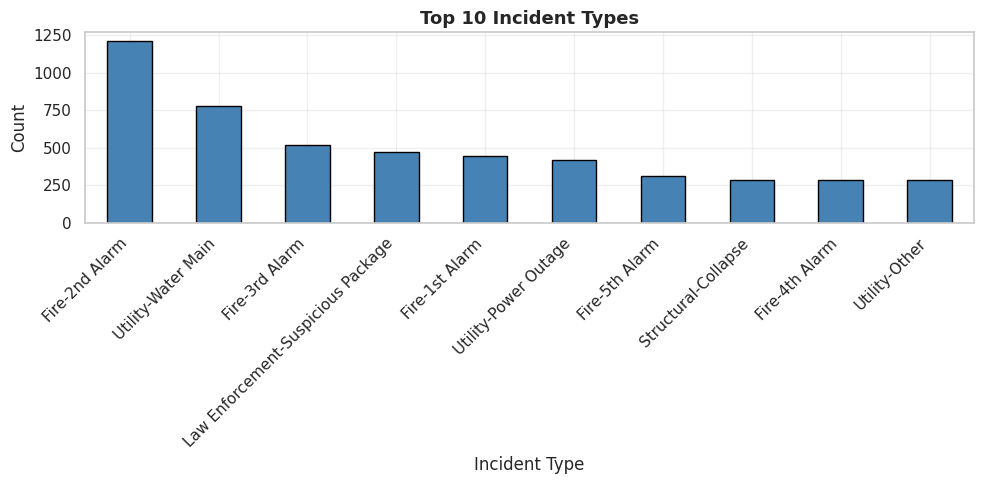


Class Distribution (%):
Incident Type
Fire-2nd Alarm                        24.13
Utility-Water Main                    15.57
Fire-3rd Alarm                        10.37
Law Enforcement-Suspicious Package     9.43
Fire-1st Alarm                         8.85
Utility-Power Outage                   8.37
Fire-5th Alarm                         6.24
Structural-Collapse                    5.74
Fire-4th Alarm                         5.64
Utility-Other                          5.64
Name: count, dtype: float64


In [108]:
# ====================================================
# CLASSIFICATION TARGET DISTRIBUTION
# ====================================================

import matplotlib.pyplot as plt

# Set your classification target column
CLASS_TARGET = "Incident Type"

# Remove missing values
target_data = df[CLASS_TARGET].dropna()


# Top 10 most common incident types
class_counts = target_data.value_counts().head(10)

plt.figure(figsize=(10, 5))

class_counts.plot(
    kind='bar',
    color='steelblue',
    edgecolor='black'
)

plt.title("Top 10 Incident Types", fontsize=13, fontweight='bold')
plt.xlabel('Incident Type')
plt.ylabel('Count')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\nClass Distribution (%):")
print((class_counts / class_counts.sum() * 100).round(2))

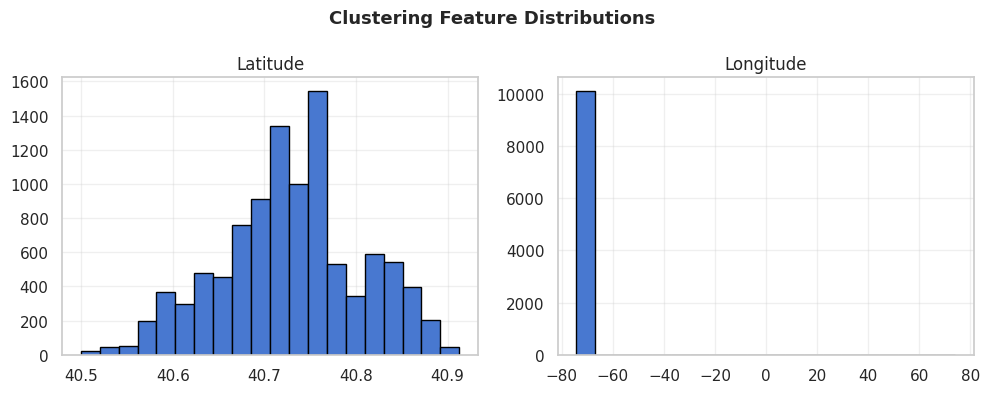

In [109]:
# ====================================================
# CLUSTERING FEATURE DISTRIBUTIONS
# ====================================================

CLUSTER_FEATURES = [
    'Latitude',
    'Longitude'
]

# Select features
cluster_features = df[CLUSTER_FEATURES].dropna()

# Plot histograms
cluster_features.hist(
    figsize=(10, 4),
    bins=20,
    edgecolor='black'
)

plt.suptitle(
    "Clustering Feature Distributions",
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

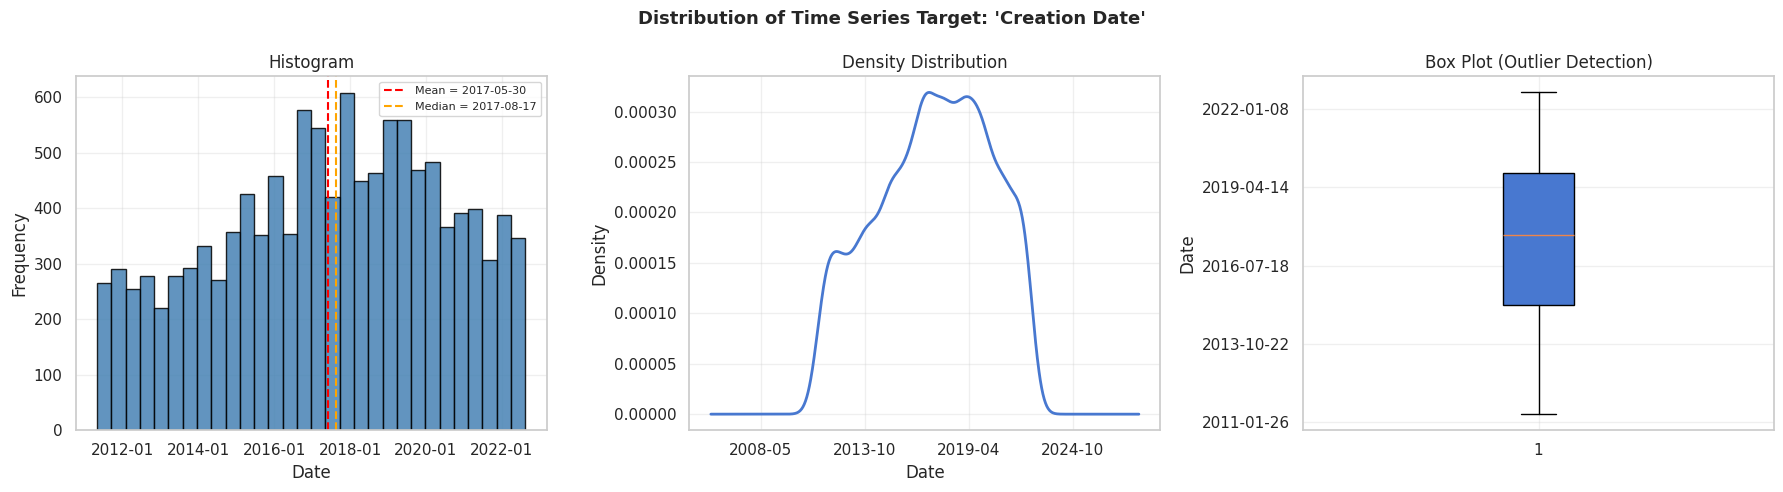

In [110]:
# ====================================================
# TIME SERIES TARGET DISTRIBUTION
# ====================================================


# Time series target column
TS_TARGET = 'Creation Date'

# Convert to datetime and remove invalid values
target_raw = pd.to_datetime(
    df[TS_TARGET],
    errors='coerce'
).dropna()

# Create plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fig.suptitle(
    f"Distribution of Time Series Target: '{TS_TARGET}'",
    fontsize=13,
    fontweight='bold'
)

# ====================================================
# HISTOGRAM
# ====================================================

axes[0].hist(
    target_raw,
    bins=30,
    color='steelblue',
    edgecolor='black',
    alpha=0.85
)

# Mean line
axes[0].axvline(
    target_raw.mean(),
    color='red',
    linestyle='--',
    label=f"Mean = {target_raw.mean().strftime('%Y-%m-%d')}"
)

# Median line
axes[0].axvline(
    target_raw.median(),
    color='orange',
    linestyle='--',
    label=f"Median = {target_raw.median().strftime('%Y-%m-%d')}"
)

axes[0].set_title('Histogram')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=8)

axes[0].xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%m')
)

# ====================================================
# KDE PLOT
# ====================================================

date_numeric = mdates.date2num(target_raw)

pd.Series(date_numeric).plot.kde(
    ax=axes[1],
    linewidth=2
)

axes[1].set_title('Density Distribution')
axes[1].set_xlabel('Date')

axes[1].xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%m')
)

# ====================================================
# BOXPLOT
# ====================================================

axes[2].boxplot(
    date_numeric,
    patch_artist=True
)

axes[2].set_title('Box Plot (Outlier Detection)')
axes[2].set_ylabel('Date')

axes[2].yaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%m-%d')
)

plt.tight_layout()
plt.show()

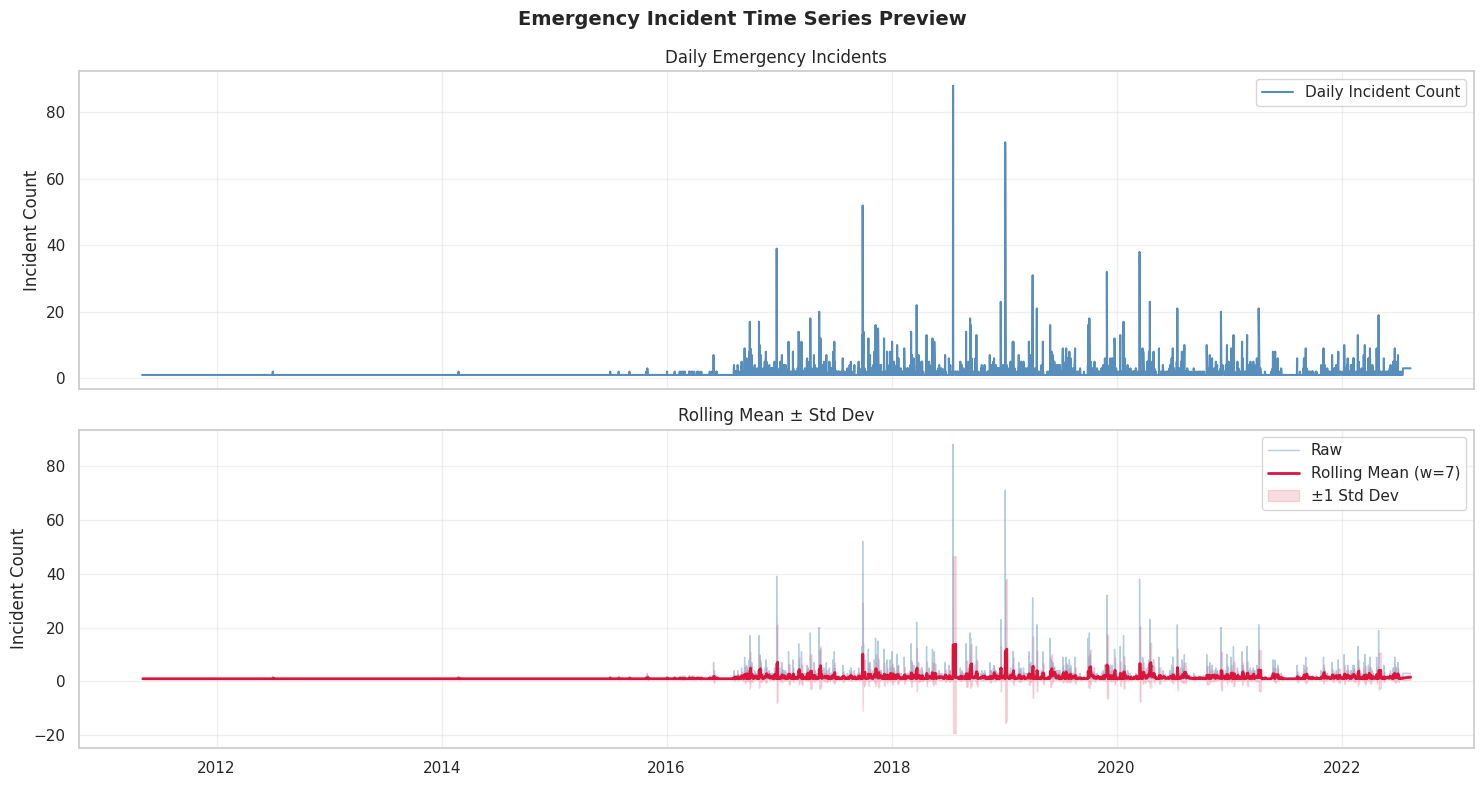

In [111]:
# ═══════════════════════════════════════════════════════════════════
# TIME SERIES PREVIEW
# ═══════════════════════════════════════════════════════════════════

import pandas as pd
import matplotlib.pyplot as plt

# Columns
DATE_COLUMN = 'Creation Date'
TS_TARGET = 'Incident Type'

# Copy dataset
df_preview = df.copy()

# Convert dates
df_preview[DATE_COLUMN] = pd.to_datetime(
    df_preview[DATE_COLUMN],
    errors='coerce'
)

# Remove invalid dates
df_preview = df_preview.dropna(subset=[DATE_COLUMN])

# Sort by date
df_preview = df_preview.sort_values(DATE_COLUMN)

# ====================================================
# CREATE DAILY INCIDENT COUNTS
# Since 'Incident Type' is categorical,
# we count incidents per day instead of plotting raw text
# ====================================================

daily_counts = (
    df_preview
    .groupby(DATE_COLUMN)
    .size()
    .reset_index(name='Incident Count')
)

# ====================================================
# ROLLING WINDOW
# 7 = weekly smoothing
# ====================================================

WINDOW = 7

daily_counts['Rolling Mean'] = (
    daily_counts['Incident Count']
    .rolling(window=WINDOW)
    .mean()
)

daily_counts['Rolling Std'] = (
    daily_counts['Incident Count']
    .rolling(window=WINDOW)
    .std()
)

# ====================================================
# PLOTS
# ====================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(15, 8),
    sharex=True
)

fig.suptitle(
    "Emergency Incident Time Series Preview",
    fontsize=14,
    fontweight='bold'
)

# ────────────────────────────────────────────────────
# RAW DAILY COUNTS
# ────────────────────────────────────────────────────

axes[0].plot(
    daily_counts[DATE_COLUMN],
    daily_counts['Incident Count'],
    color='steelblue',
    linewidth=1.5,
    alpha=0.9,
    label='Daily Incident Count'
)

axes[0].set_ylabel('Incident Count')
axes[0].set_title('Daily Emergency Incidents')
axes[0].legend()

# ────────────────────────────────────────────────────
# ROLLING STATISTICS
# ────────────────────────────────────────────────────

axes[1].plot(
    daily_counts[DATE_COLUMN],
    daily_counts['Incident Count'],
    color='steelblue',
    linewidth=1,
    alpha=0.4,
    label='Raw'
)

axes[1].plot(
    daily_counts[DATE_COLUMN],
    daily_counts['Rolling Mean'],
    color='crimson',
    linewidth=2,
    label=f'Rolling Mean (w={WINDOW})'
)

axes[1].fill_between(
    daily_counts[DATE_COLUMN],
    daily_counts['Rolling Mean'] - daily_counts['Rolling Std'],
    daily_counts['Rolling Mean'] + daily_counts['Rolling Std'],
    color='crimson',
    alpha=0.15,
    label='±1 Std Dev'
)

axes[1].set_ylabel('Incident Count')
axes[1].set_title('Rolling Mean ± Std Dev')
axes[1].legend()

plt.tight_layout()
plt.show()

# Phase 3 - Data Preparation

3.1 Data Cleaning

In [112]:
# ═══════════════════════════════════════════════════════════════════
# Data Cleaning: Applicable to Classification, Clustering, Time Series
# ═══════════════════════════════════════════════════════════════════

# Work on a copy so the original dataset remains untouched
df_cleaned = df.copy()

# 1. Standardize column names to snake_case for easier handling
df_cleaned.columns = (
    df_cleaned.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
)

# 2. Convert date columns to proper datetime format
# These are essential for time-based analysis
date_cols = ['creation_date', 'closed_date']
for col in date_cols:
    if col in df_cleaned.columns:
        df_cleaned[col] = pd.to_datetime(df_cleaned[col], errors='coerce')

# 3. Remove rows where critical fields are missing
# These fields are required by the three models
df_cleaned.dropna(subset=['incident_type', 'borough', 'creation_date'], inplace=True)

# 4. Create useful time features from creation_date
# These will help the classification model learn patterns
df_cleaned['hour'] = df_cleaned['creation_date'].dt.hour
df_cleaned['day_of_week'] = df_cleaned['creation_date'].dt.dayofweek
df_cleaned['month'] = df_cleaned['creation_date'].dt.month

# 5. Handle missing geographic coordinates
# For clustering, we need latitude and longitude
# Instead of dropping all rows, keep a separate geo-ready subset later
# Here we just note they exist
print("Rows with missing coordinates:",
      df_cleaned[['latitude', 'longitude']].isnull().any(axis=1).sum())

# 6. Optional: Create response time feature (in hours)
# Useful additional feature for analysis
df_cleaned['response_hours'] = (
    (df_cleaned['closed_date'] - df_cleaned['creation_date'])
    .dt.total_seconds() / 3600
)

# 7. Remove duplicate records as a safety step
df_cleaned.drop_duplicates(inplace=True)

print("Data cleaning applied to df_cleaned")
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_cleaned.shape}")

# 8. Check if any important columns still have missing values
print("\nRemaining missing values in key columns:")
key_cols = ['incident_type', 'borough', 'creation_date',
            'latitude', 'longitude']
print(df_cleaned[key_cols].isnull().sum())

Rows with missing coordinates: 1625
Data cleaning applied to df_cleaned
Original shape: (11750, 7)
Cleaned shape: (9911, 11)

Remaining missing values in key columns:
incident_type       0
borough             0
creation_date       0
latitude         1427
longitude        1427
dtype: int64


3.2 Shared Transformation

In [113]:
# ═══════════════════════════════════════════════════════════════════
# Shared Feature Engineering for All Models
# ═══════════════════════════════════════════════════════════════════

df_features = df_cleaned.copy()

# -------------------------------------------------------
# 1. Time-based features from creation_date
# -------------------------------------------------------
# These help reveal temporal patterns of incidents

df_features['year'] = df_features['creation_date'].dt.year
df_features['month'] = df_features['creation_date'].dt.month
df_features['day'] = df_features['creation_date'].dt.day
df_features['hour'] = df_features['creation_date'].dt.hour
df_features['day_of_week'] = df_features['creation_date'].dt.dayofweek
df_features['is_weekend'] = df_features['day_of_week'].isin([5, 6]).astype(int)

# -------------------------------------------------------
# 1B. Advanced temporal features
# -------------------------------------------------------

# Rush hour indicator
df_features['is_rush_hour'] = (
    df_features['hour'].isin([7,8,9,16,17,18])
).astype(int)

# Night incidents
df_features['is_night'] = (
    (df_features['hour'] >= 22) |
    (df_features['hour'] <= 5)
).astype(int)

# Quarter of the year
df_features['quarter'] = df_features['creation_date'].dt.quarter

# Simple season mapping
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df_features['season'] = df_features['month'].apply(get_season)

# -------------------------------------------------------
# 2. Incident duration / response time
# -------------------------------------------------------
# Useful indicator for analysis and may help classification

df_features['response_hours'] = (
    (df_features['closed_date'] - df_features['creation_date'])
    .dt.total_seconds() / 3600
)

# Replace negative or extreme values if any (data errors)
df_features.loc[df_features['response_hours'] < 0, 'response_hours'] = np.nan

# -------------------------------------------------------
# 3. Encode borough into numeric form
# -------------------------------------------------------
# Required for machine learning models

from sklearn.preprocessing import LabelEncoder

le_borough = LabelEncoder()
df_features['borough_enc'] = le_borough.fit_transform(df_features['borough'])

# -------------------------------------------------------
# 4. Basic location sanity check
# -------------------------------------------------------
# Remove impossible coordinates (outside valid lat/long range)

df_features = df_features[
    (df_features['latitude'].between(-90, 90)) &
    (df_features['longitude'].between(-180, 180))
]

# -------------------------------------------------------
# 5. Create incident count per day (for time series support)
# -------------------------------------------------------
daily_counts = (
    df_features
    .set_index('creation_date')
    .resample('D')
    .size()
    .rename('daily_incident_count')
)

print("Shared feature engineering completed.")
print("New columns added:")
print([
    'year', 'month', 'day', 'hour',
    'day_of_week', 'is_weekend',
    'response_hours', 'borough_enc',
    'is_rush_hour', 'is_night', 'quarter',
    'season', 'daily_incident_count'
])

Shared feature engineering completed.
New columns added:
['year', 'month', 'day', 'hour', 'day_of_week', 'is_weekend', 'response_hours', 'borough_enc', 'is_rush_hour', 'is_night', 'quarter', 'season', 'daily_incident_count']


3.3 Separate Model Pipeline

3.3.1 Classification Prep

In [114]:
class_df = df_features.copy()

# ====================================================
# INCIDENT CATEGORY GROUPING
# ====================================================

def group_incident_type(x):

    x = str(x).lower()

    if any(word in x for word in [
        'fire', 'smoke', 'burn'
    ]):
        return 'Fire'

    elif any(word in x for word in [
        'medical', 'injury', 'sick',
        'ambulance', 'health'
    ]):
        return 'Medical'

    elif any(word in x for word in [
        'traffic', 'vehicle', 'collision',
        'car', 'accident'
    ]):
        return 'Traffic'

    elif any(word in x for word in [
        'crime', 'assault', 'violence',
        'weapon', 'police'
    ]):
        return 'Public Safety'

    elif any(word in x for word in [
        'water', 'flood', 'storm',
        'weather'
    ]):
        return 'Weather'

    else:
        return 'Other'

class_df['incident_group'] = (
    class_df['incident_type']
    .apply(group_incident_type)
)

# ====================================================
# CHECK NEW CLASS DISTRIBUTION
# ====================================================

print("\nGrouped Incident Categories:")
print(class_df['incident_group'].value_counts())

print("\nNumber of grouped classes:")
print(class_df['incident_group'].nunique())


Grouped Incident Categories:
incident_group
Other            4265
Fire             2943
Weather           797
Traffic           387
Medical            91
Public Safety       1
Name: count, dtype: int64

Number of grouped classes:
6


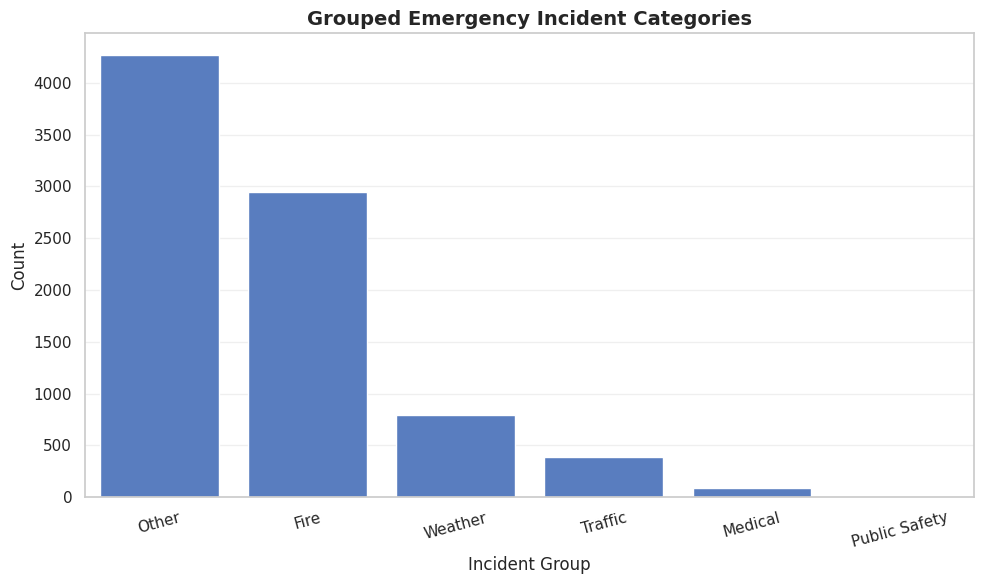

In [115]:
# ====================================================
# VISUALIZE GROUPED INCIDENT TYPES
# ====================================================

plt.figure(figsize=(10,6))

sns.countplot(
    data=class_df,
    x='incident_group',
    order=class_df['incident_group'].value_counts().index
)

plt.title(
    'Grouped Emergency Incident Categories',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Incident Group')
plt.ylabel('Count')

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [116]:
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder


y_class = class_df['incident_group']

# ====================================================
# REMOVE EXTREMELY RARE CLASSES
# ====================================================

class_counts = y_class.value_counts()

valid_classes = class_counts[class_counts >= 2].index

class_df = class_df[
    class_df['incident_group'].isin(valid_classes)
]

# Recreate target after filtering
y_class = class_df['incident_group']

print("Remaining classes:")
print(y_class.value_counts())

# ====================================================
# LABEL ENCODING FOR XGBOOST
# ====================================================

label_encoder = LabelEncoder()

y_class = label_encoder.fit_transform(y_class)

X_class = class_df.drop(columns=[
    'incident_group',
    'creation_date',
    'closed_date',
    'latitude',
    'longitude',
    'location' # Drop high-cardinality 'location' column
], errors='ignore')

X_class = pd.get_dummies(X_class, drop_first=True)

# Impute missing values in numerical columns (e.g., 'response_hours')
imputer = SimpleImputer(strategy='mean')
numerical_cols = X_class.select_dtypes(include=np.number).columns
X_class[numerical_cols] = imputer.fit_transform(X_class[numerical_cols])

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_class, y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

# ====================================================
# HANDLE CLASS IMBALANCE USING SMOTE
# ====================================================

smote = SMOTE(random_state=42)

Xc_train, yc_train = smote.fit_resample(
    Xc_train,
    yc_train
)

print("\nAfter SMOTE:")
print(pd.Series(yc_train).value_counts())

print("Classification data ready")
print("Training shape:", Xc_train.shape)

Remaining classes:
incident_group
Other      4265
Fire       2943
Weather     797
Traffic     387
Medical      91
Name: count, dtype: int64

After SMOTE:
2    3412
0    3412
3    3412
4    3412
1    3412
Name: count, dtype: int64
Classification data ready
Training shape: (17060, 474)


3.3.2 Clustering Prep

In [117]:
# ====================================================
# GEOGRAPHIC CLUSTERING PREPARATION
# ====================================================

cluster_geo_df = df_features.copy()

# ----------------------------------------------------
# USE GEOGRAPHIC FEATURES
# ----------------------------------------------------

geo_features = [
    'latitude',
    'longitude'
]

cluster_geo_df = (
    cluster_geo_df[geo_features]
    .dropna()
)

# ----------------------------------------------------
# REMOVE INVALID COORDINATES
# ----------------------------------------------------

cluster_geo_df = cluster_geo_df[
    (cluster_geo_df['latitude'] != 0) &
    (cluster_geo_df['longitude'] != 0)
]

print("Geographic clustering data ready")
print(cluster_geo_df.shape)

# ----------------------------------------------------
# SCALE COORDINATES
# ----------------------------------------------------

scaler = StandardScaler()

X_geo_cluster = scaler.fit_transform(cluster_geo_df)

Geographic clustering data ready
(8484, 2)


3.3.3 Time Series Prep

In [118]:
# ═══════════════════════════════════════════════════════════════════
# Time Series Construction — Daily Incident Counts
# ═══════════════════════════════════════════════════════════════════

ts = (
    df_features
    .set_index('creation_date')
    .resample('D')
    .size()
    .to_frame('daily_incidents')
)

ts.index = pd.to_datetime(ts.index)
TARGET_COLUMN = 'daily_incidents'
FREQ = 'D'

print(ts.head())

               daily_incidents
creation_date                 
2011-05-04                   4
2011-05-05                   0
2011-05-06                   5
2011-05-07                   3
2011-05-08                   1


In [119]:
# Missing values
missing_count = ts[TARGET_COLUMN].isna().sum()
print("Missing values:", missing_count)

# Implicit gaps
full_idx = pd.date_range(ts.index.min(), ts.index.max(), freq=FREQ)
missing_dates = full_idx.difference(ts.index)
print("Implicit gap periods:", len(missing_dates))

# Reindex to complete timeline
ts = ts.reindex(full_idx)

# Fill using median (robust)
ts[TARGET_COLUMN] = ts[TARGET_COLUMN].fillna(ts[TARGET_COLUMN].median())

print("Gap handling complete")

Missing values: 0
Implicit gap periods: 0
Gap handling complete


Outliers detected: 91


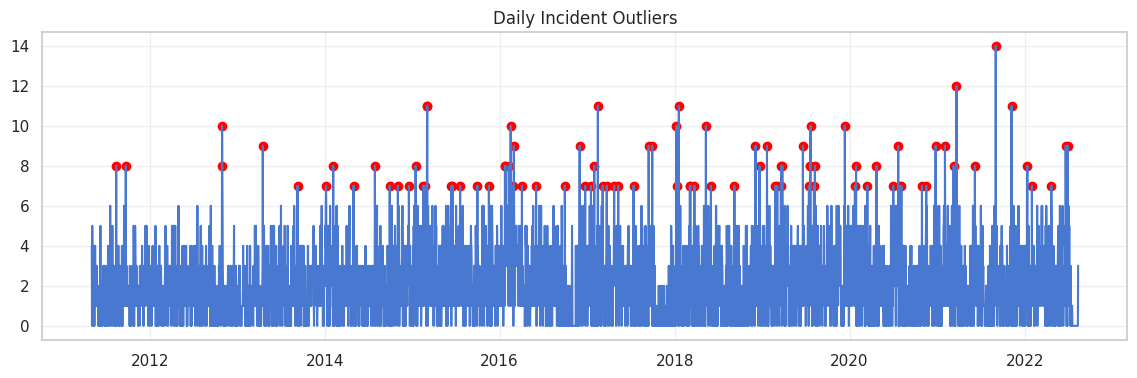

In [120]:
# ============================================================
# Detect extreme outliers
# ============================================================



Q1 = ts['daily_incidents'].quantile(0.25)
Q3 = ts['daily_incidents'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = ts[(ts['daily_incidents'] < lower) |
              (ts['daily_incidents'] > upper)]

print("Outliers detected:", len(outliers))

plt.figure(figsize=(14,4))
plt.plot(ts.index, ts['daily_incidents'])
plt.scatter(outliers.index, outliers['daily_incidents'], color='red')
plt.title("Daily Incident Outliers")
plt.show()

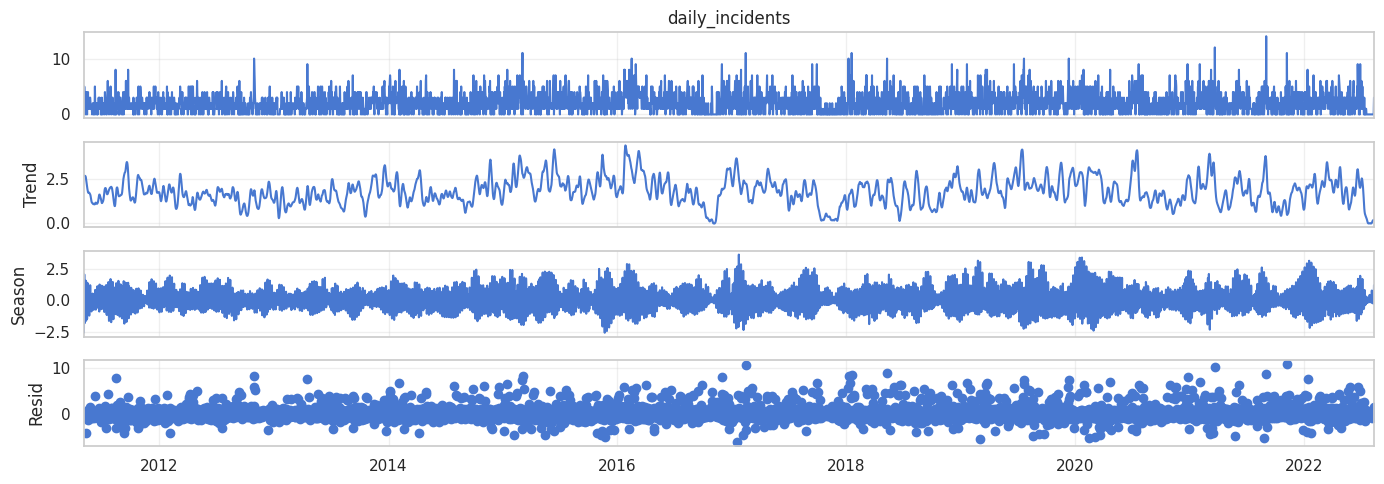

In [121]:
# ============================================================
# STL Decomposition (weekly pattern = 7 days)
# ============================================================


stl = STL(ts['daily_incidents'], period=7, robust=True)
res = stl.fit()
res.plot()
plt.show()

In [122]:
# ============================================================
# Variance Stabilization for forecasting
# ============================================================

import numpy as np

ts_log = np.log1p(ts['daily_incidents'])

In [123]:
# ============================================================
# ADF & KPSS Tests
# ============================================================

from statsmodels.tsa.stattools import adfuller, kpss

def test_stationarity(series):
    adf_p = adfuller(series.dropna())[1]
    kpss_p = kpss(series.dropna(), regression='c')[1]
    print(f"ADF p-value : {adf_p}")
    print(f"KPSS p-value: {kpss_p}")

test_stationarity(ts_log)

ADF p-value : 5.278742994950834e-13
KPSS p-value: 0.1


In [124]:
# ============================================================
# Differencing to make series stationary
# ============================================================

ts_diff = ts_log.diff().dropna()
test_stationarity(ts_diff)

ADF p-value : 0.0
KPSS p-value: 0.1


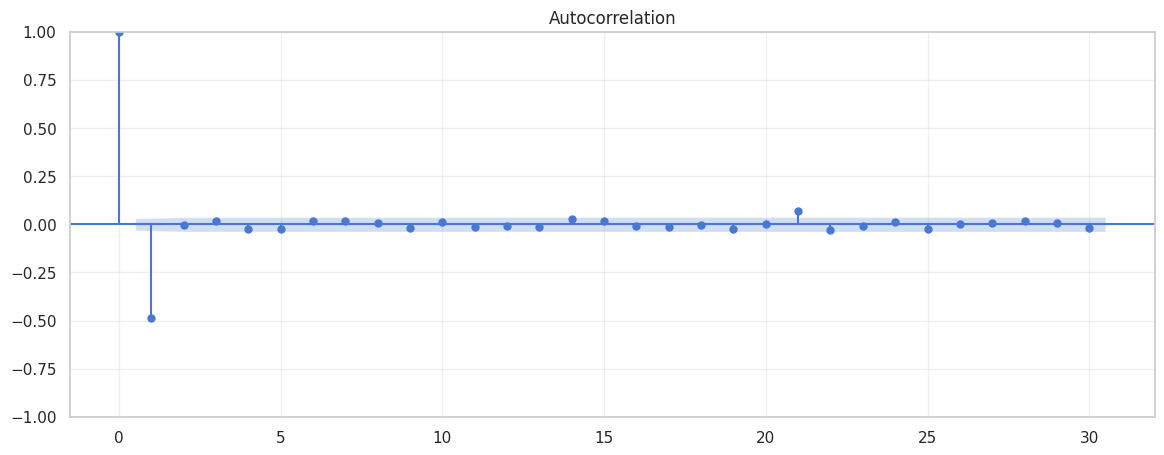

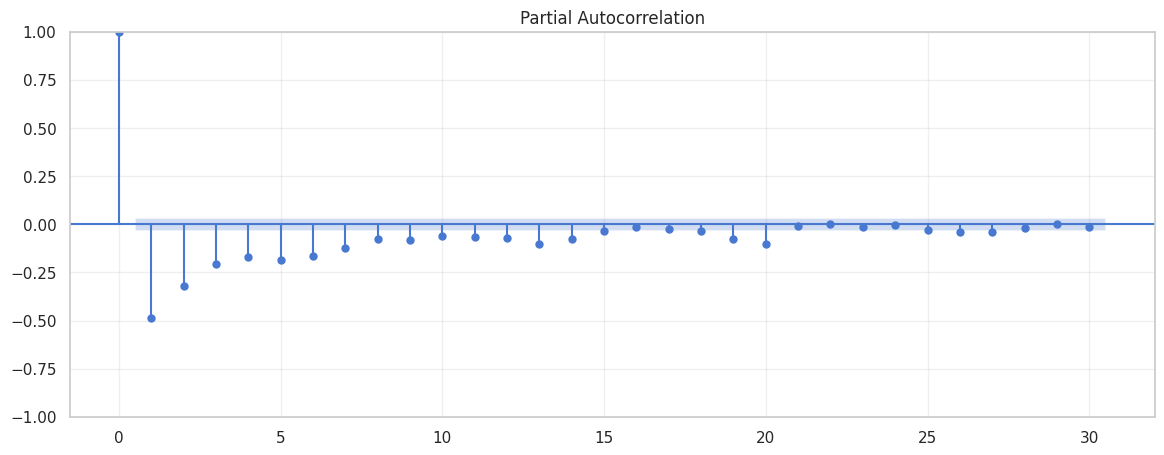

In [125]:
# ============================================================
# ACF and PACF for SARIMA order selection
# ============================================================

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(ts_diff, lags=30)
plot_pacf(ts_diff, lags=30)
plt.show()

Non-seasonal differencing applied (d): 2
Seasonal differencing applied (D): 0, PERIOD: 7


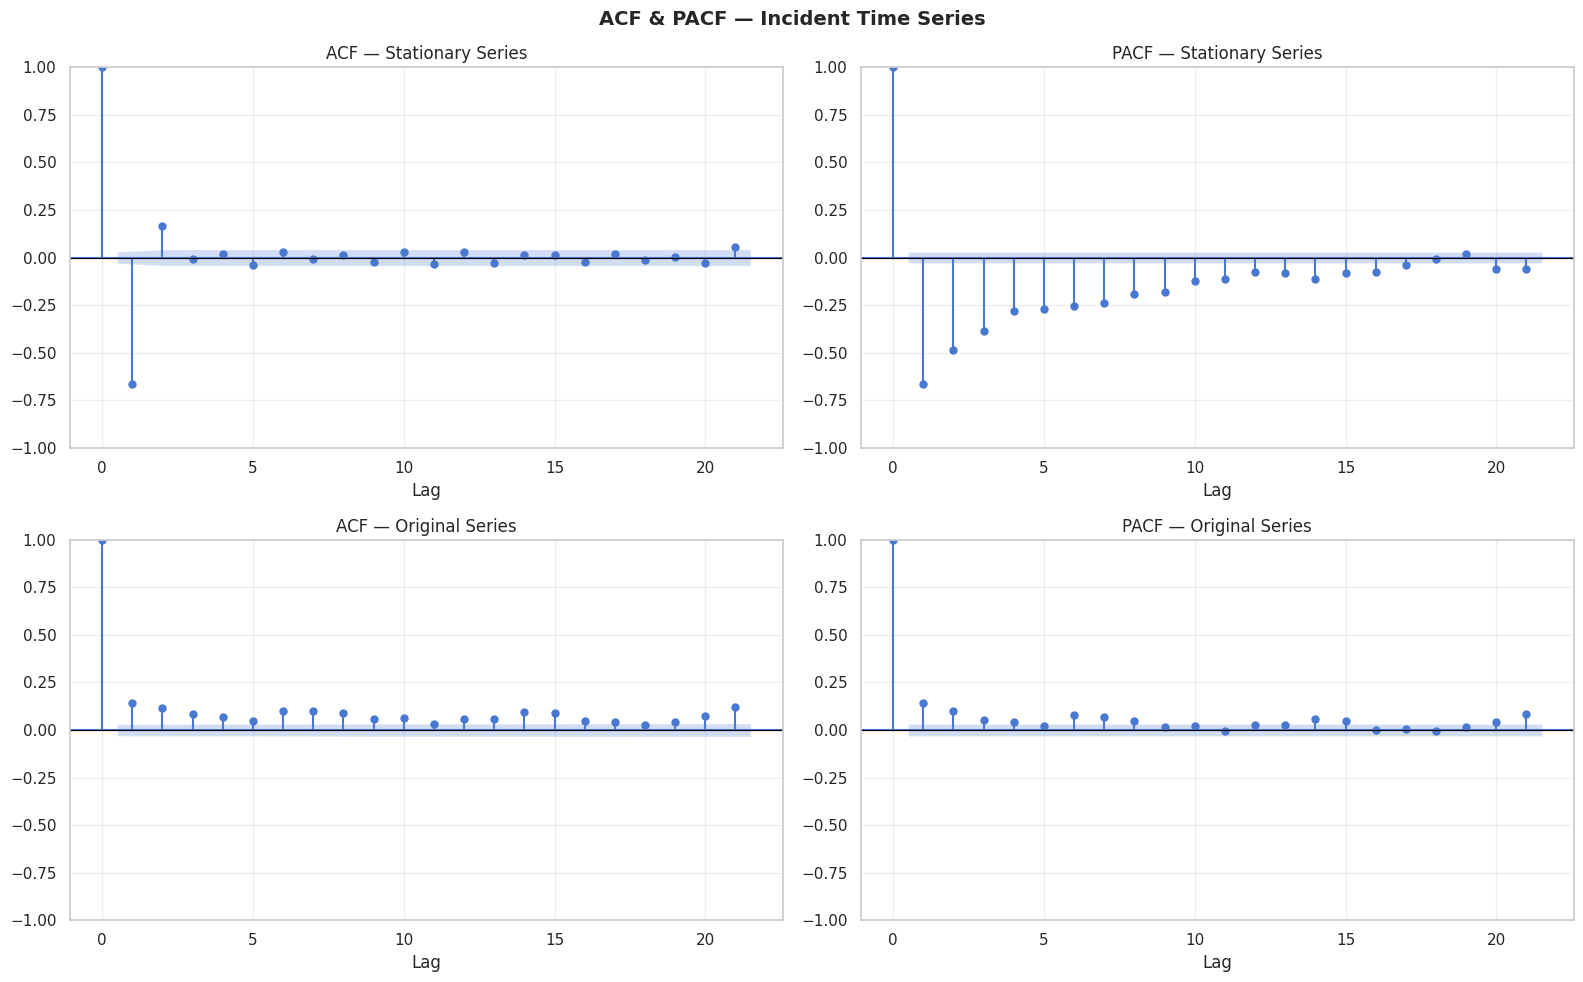


Significant ACF lags:
 Lag       ACF
   1 -0.663561
   2  0.168271
   5 -0.038380
   6  0.031399
  11 -0.031720

Significant PACF lags:
 Lag      PACF
   1 -0.663561
   2 -0.486061
   3 -0.387298
   4 -0.282100
   5 -0.269971
   6 -0.253184
   7 -0.238217
   8 -0.189326
   9 -0.180073
  10 -0.124675
  11 -0.113950
  12 -0.074679
  13 -0.083848
  14 -0.115345

MODEL GUIDANCE:
Trend detected but no seasonality → ARIMA model recommended.


In [126]:
# ═══════════════════════════════════════════════════════════════════
# ACF & PACF Analysis for Emergency Incidents Time Series
# Based on df_features from shared feature engineering
# ═══════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf

# -------------------------------------------------------
# 1. Build DAILY incident count time series
# -------------------------------------------------------
ts = (
    df_features
    .set_index('creation_date')
    .resample('D')
    .size()
    .rename('daily_incidents')
)

ts = ts.asfreq('D').fillna(0)

# -------------------------------------------------------
# 2. Check stationarity (ADF and KPSS)
# -------------------------------------------------------
def check_stationarity(series):
    adf_p  = adfuller(series)[1]
    kpss_p = kpss(series, regression='c', nlags='auto')[1]
    return adf_p < 0.05, kpss_p > 0.05

adf_ok, kpss_ok = check_stationarity(ts)

# -------------------------------------------------------
# 3. Differencing if needed
# -------------------------------------------------------
d = 0
ts_stationary = ts.copy()

while not (adf_ok and kpss_ok):
    ts_stationary = ts_stationary.diff().dropna()
    d += 1
    adf_ok, kpss_ok = check_stationarity(ts_stationary)

print(f"Non-seasonal differencing applied (d): {d}")

# -------------------------------------------------------
# 4. Assume weekly seasonality (common in incidents)
# -------------------------------------------------------
PERIOD = 7   # weekly pattern
D = 0

ts_seasonal = ts_stationary.copy()

adf_ok, kpss_ok = check_stationarity(ts_seasonal)

if not (adf_ok and kpss_ok):
    ts_seasonal = ts_seasonal.diff(PERIOD).dropna()
    D = 1

print(f"Seasonal differencing applied (D): {D}, PERIOD: {PERIOD}")

# -------------------------------------------------------
# 5. Plot ACF and PACF
# -------------------------------------------------------
MAX_LAGS = min(3 * PERIOD, len(ts_seasonal)//2 - 1)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('ACF & PACF — Incident Time Series', fontsize=14, fontweight='bold')

plot_acf(ts_seasonal, lags=MAX_LAGS, ax=axes[0,0], alpha=0.05,
         title='ACF — Stationary Series')

plot_pacf(ts_seasonal, lags=MAX_LAGS, ax=axes[0,1], alpha=0.05,
          method='ywm', title='PACF — Stationary Series')

plot_acf(ts, lags=MAX_LAGS, ax=axes[1,0], alpha=0.05,
         title='ACF — Original Series')

plot_pacf(ts, lags=MAX_LAGS, ax=axes[1,1], alpha=0.05,
          method='ywm', title='PACF — Original Series')

for ax in axes.flat:
    ax.set_xlabel('Lag')
    ax.axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

# -------------------------------------------------------
# 6. Print significant lags
# -------------------------------------------------------
n_lags_table = min(2 * PERIOD, len(ts_seasonal)//2)

acf_vals  = acf(ts_seasonal.dropna(), nlags=n_lags_table, alpha=0.05)
pacf_vals = pacf(ts_seasonal.dropna(), nlags=n_lags_table, alpha=0.05, method='ywm')

acf_df = pd.DataFrame({
    'Lag' : range(n_lags_table + 1),
    'ACF' : acf_vals[0],
    'PACF': pacf_vals[0],
})

acf_df['ACF_sig'] = np.abs(acf_df['ACF']) > (1.96/np.sqrt(len(ts_seasonal)))
acf_df['PACF_sig'] = np.abs(acf_df['PACF']) > (1.96/np.sqrt(len(ts_seasonal)))

print("\nSignificant ACF lags:")
print(acf_df[acf_df['ACF_sig'] & (acf_df['Lag'] > 0)][['Lag','ACF']].to_string(index=False))

print("\nSignificant PACF lags:")
print(acf_df[acf_df['PACF_sig'] & (acf_df['Lag'] > 0)][['Lag','PACF']].to_string(index=False))

# -------------------------------------------------------
# 7. Model suggestion based on results
# -------------------------------------------------------
print("\nMODEL GUIDANCE:")
if D > 0:
    print("Seasonality detected → SARIMA model recommended.")
elif d > 0:
    print("Trend detected but no seasonality → ARIMA model recommended.")
else:
    print("Series already stationary → ARMA model may be sufficient.")

# Phase 4 - Modeling

4.1 Classification Model

In [127]:
import time

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB

cls_models = {

    'Logistic Regression': LogisticRegression(
        max_iter=300,
        random_state=42,
        n_jobs=-1
    ),

    'Decision Tree': DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=30,      # reduced from 100
        max_depth=8,          # reduced complexity
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ),

    'XGBoost': XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        objective='multi:softmax',
        eval_metric='mlogloss',
        random_state=42
    ),

    'Naive Bayes': GaussianNB()
}

# ====================================================
# RESULTS STORAGE
# ====================================================

cls_results = {}

# ====================================================
# TRAIN & EVALUATE
# ====================================================

for name, model in cls_models.items():

    print(f"\nTraining: {name}")

    start_time = time.time()

    try:

        # ====================================================
        # SCALE ONLY NECESSARY MODELS
        # ====================================================

        if name in ['Logistic Regression', 'Naive Bayes']:

            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('model', model)
            ])

            pipeline.fit(Xc_train, yc_train)

            y_pred = pipeline.predict(Xc_test)

            trained_model = pipeline

        else:

            model.fit(Xc_train, yc_train)

            y_pred = model.predict(Xc_test)

            trained_model = model

        # ====================================================
        # METRICS
        # ====================================================

        cls_results[name] = {

            'model': trained_model,

            'accuracy': accuracy_score(
                yc_test,
                y_pred
            ),

            'precision': precision_score(
                yc_test,
                y_pred,
                average='weighted',
                zero_division=0
            ),

            'recall': recall_score(
                yc_test,
                y_pred,
                average='weighted',
                zero_division=0
            ),

            'f1': f1_score(
                yc_test,
                y_pred,
                average='weighted',
                zero_division=0
            )
        }

        end_time = time.time()

        print(
            f"[{name}] "
            f"Acc={cls_results[name]['accuracy']:.3f} | "
            f"F1={cls_results[name]['f1']:.3f} | "
            f"Time={(end_time - start_time):.2f}s"
        )

    except Exception as e:

        print(f"❌ Error in {name}: {e}")

# ====================================================
# BEST MODEL
# ====================================================

best_cls_name = max(
    cls_results,
    key=lambda k: cls_results[k]['f1']
)

best_cls_model = cls_results[best_cls_name]['model']

print(f"\n✅ Best Classifier: {best_cls_name}")


Training: Logistic Regression
[Logistic Regression] Acc=0.985 | F1=0.986 | Time=4.75s

Training: Decision Tree
[Decision Tree] Acc=0.733 | F1=0.704 | Time=0.45s

Training: Random Forest
[Random Forest] Acc=0.923 | F1=0.923 | Time=0.72s

Training: XGBoost
[XGBoost] Acc=0.985 | F1=0.985 | Time=19.19s

Training: Naive Bayes
[Naive Bayes] Acc=0.973 | F1=0.980 | Time=1.14s

✅ Best Classifier: Logistic Regression


4.2 Clustering Model

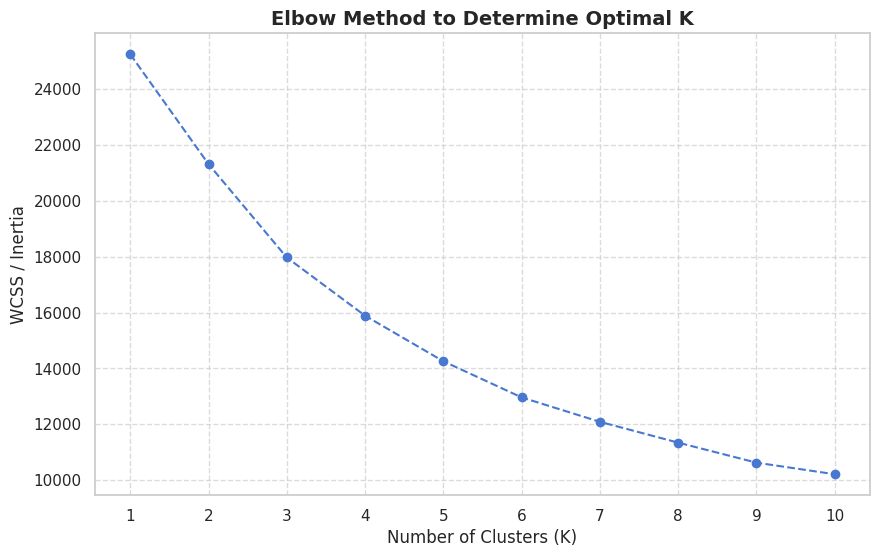

In [128]:
# ====================================================
# ELBOW METHOD
# ====================================================

wcss = []

K_range = range(1, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_cluster)

    wcss.append(kmeans.inertia_)

# ====================================================
# PLOT ELBOW METHOD
# ====================================================

plt.figure(figsize=(10, 6))

plt.plot(
    K_range,
    wcss,
    marker='o',
    linestyle='--'
)

plt.title(
    'Elbow Method to Determine Optimal K',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS / Inertia')

plt.xticks(list(K_range))

plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

In [129]:
# ====================================================
# DBSCAN GEOGRAPHIC HOTSPOT CLUSTERING
# ====================================================

from sklearn.cluster import DBSCAN

# ----------------------------------------------------
# DBSCAN MODEL
# ----------------------------------------------------

dbscan = DBSCAN(
    eps=0.15,
    min_samples=15
)

cluster_labels = dbscan.fit_predict(
    X_geo_cluster
)

# ----------------------------------------------------
# ATTACH CLUSTERS
# ----------------------------------------------------

cluster_geo_df['cluster'] = cluster_labels

# ----------------------------------------------------
# SUMMARY
# ----------------------------------------------------

print("=" * 55)
print(" DBSCAN CLUSTERING RESULTS")
print("=" * 55)

print(
    cluster_geo_df['cluster']
    .value_counts()
    .sort_index()
)

print("\nUnique Clusters Found:")
print(cluster_geo_df['cluster'].nunique())

# Noise points
noise_points = (cluster_labels == -1).sum()

print(f"\nNoise Points: {noise_points}")

 DBSCAN CLUSTERING RESULTS
cluster
-1       2
 0    8482
Name: count, dtype: int64

Unique Clusters Found:
2

Noise Points: 2


4.3 Time Series Model

In [130]:
# ====================================================
# PREPARE TIME SERIES DATA
# ====================================================

# Date column
DATE_COLUMN = 'Creation Date'

# Convert to datetime
df[DATE_COLUMN] = pd.to_datetime(
    df[DATE_COLUMN],
    errors='coerce'
)

# Remove invalid dates
ts_df = df.dropna(subset=[DATE_COLUMN]).copy()

# ====================================================
# CREATE DAILY INCIDENT COUNTS
# ====================================================

ts_model = (
    ts_df
    .groupby(DATE_COLUMN)
    .size()
    .rename('incident_count')
)

# Ensure sorted index
ts_model = ts_model.sort_index()

Training : 2011-05-04 → 2022-07-12 (8604 periods)
Test     : 2022-07-15 → 2022-08-12 (7 periods)
Split    : 99.9% train / 0.1% test


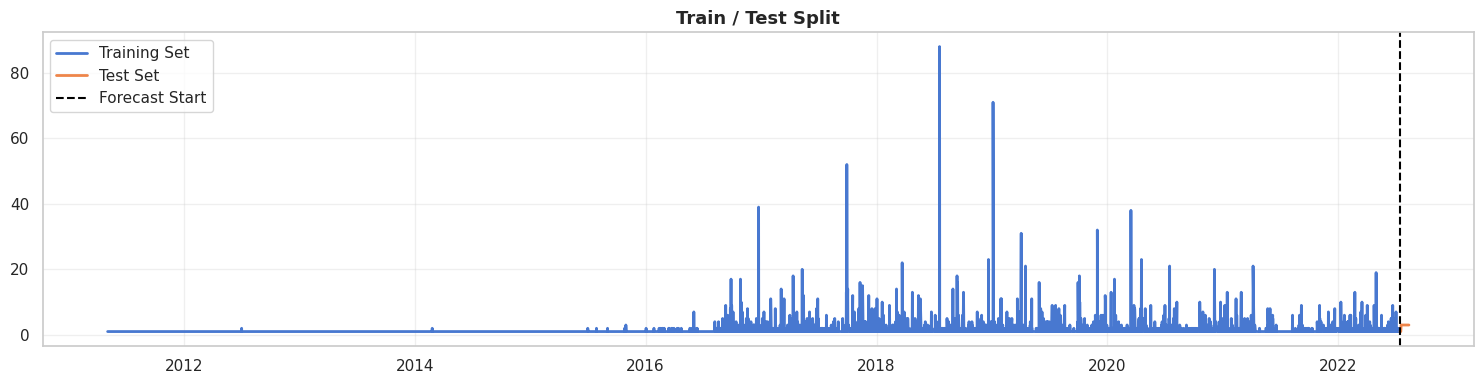

In [131]:
# ====================================================
# TRAIN / TEST SPLIT
# ====================================================

# Weekly seasonality for daily data
PERIOD = 7

# Hold out last seasonal cycle
FORECAST_HORIZON = PERIOD

train = ts_model.iloc[:-FORECAST_HORIZON]
test = ts_model.iloc[-FORECAST_HORIZON:]

print(
    f"Training : {train.index.min().date()} → "
    f"{train.index.max().date()} "
    f"({len(train)} periods)"
)

print(
    f"Test     : {test.index.min().date()} → "
    f"{test.index.max().date()} "
    f"({len(test)} periods)"
)

print(
    f"Split    : "
    f"{len(train)/len(ts_model)*100:.1f}% train / "
    f"{len(test)/len(ts_model)*100:.1f}% test"
)

# ====================================================
# VISUALIZE SPLIT
# ====================================================

plt.figure(figsize=(15, 4))

plt.plot(
    train,
    linewidth=2,
    label='Training Set'
)

plt.plot(
    test,
    linewidth=2,
    label='Test Set'
)

plt.axvline(
    x=test.index[0],
    color='black',
    linestyle='--',
    linewidth=1.5,
    label='Forecast Start'
)

plt.title(
    'Train / Test Split',
    fontsize=13,
    fontweight='bold'
)

plt.legend()

plt.tight_layout()
plt.show()

In [132]:
# ====================================================
# AUTO SARIMA SEARCH
# ====================================================

import pmdarima as pm

# ====================================================
# DIFFERENCING PARAMETERS
# Common defaults for incident count forecasting
# ====================================================

d = 1
D = 1

# ====================================================
# SEARCH SPACE
# Reduced ranges for faster execution
# ====================================================

p_range = range(0, 3)
q_range = range(0, 3)

P_range = range(0, 2)
Q_range = range(0, 2)

s = PERIOD

print(
    f"Searching optimal SARIMA parameters..."
)

# Remove any NaNs
train_clean = train.dropna()

# ====================================================
# AUTO ARIMA
# ====================================================

optimized_sarima_model = pm.auto_arima(
    train_clean,

    start_p=min(p_range),
    max_p=max(p_range),

    start_q=min(q_range),
    max_q=max(q_range),

    d=d,

    start_P=min(P_range),
    max_P=max(P_range),

    start_Q=min(Q_range),
    max_Q=max(Q_range),

    D=D,

    seasonal=True,
    m=s,

    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',

    trace=True,

    random_state=42,

    n_fits=20
)

print("\nOptimal SARIMA Parameters:")
print(optimized_sarima_model.summary())

# ====================================================
# EXTRACT BEST PARAMETERS
# ====================================================

best_order = optimized_sarima_model.order
best_seasonal_order = optimized_sarima_model.seasonal_order

print(f"\n✅ Best Order: {best_order}")
print(f"✅ Best Seasonal Order: {best_seasonal_order}")

Searching optimal SARIMA parameters...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[7]             : AIC=48339.360, Time=0.47 sec
 ARIMA(1,1,0)(1,1,0)[7]             : AIC=43392.268, Time=0.75 sec
 ARIMA(0,1,1)(0,1,1)[7]             : AIC=inf, Time=11.26 sec
 ARIMA(1,1,0)(0,1,0)[7]             : AIC=45894.447, Time=0.18 sec
 ARIMA(1,1,0)(1,1,1)[7]             : AIC=inf, Time=5.74 sec
 ARIMA(1,1,0)(0,1,1)[7]             : AIC=inf, Time=5.08 sec
 ARIMA(0,1,0)(1,1,0)[7]             : AIC=45859.835, Time=0.63 sec
 ARIMA(2,1,0)(1,1,0)[7]             : AIC=42407.169, Time=1.36 sec
 ARIMA(2,1,0)(0,1,0)[7]             : AIC=44935.814, Time=0.41 sec
 ARIMA(2,1,0)(1,1,1)[7]             : AIC=inf, Time=12.88 sec
 ARIMA(2,1,0)(0,1,1)[7]             : AIC=inf, Time=5.92 sec
 ARIMA(2,1,1)(1,1,0)[7]             : AIC=inf, Time=11.68 sec
 ARIMA(1,1,1)(1,1,0)[7]             : AIC=inf, Time=9.33 sec
 ARIMA(2,1,0)(1,1,0)[7] intercept   : AIC=42409.169, Time=3.25 sec

Best model:  ARIMA

In [133]:
# ====================================================
# FINAL SARIMA MODEL
# ====================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX

BEST_ORDER = best_order
BEST_SEASONAL_ORDER = best_seasonal_order

final_model = SARIMAX(
    train,

    order=BEST_ORDER,

    seasonal_order=BEST_SEASONAL_ORDER,

    enforce_stationarity=False,
    enforce_invertibility=False
)

# ====================================================
# FIT MODEL
# ====================================================

final_result = final_model.fit(disp=False)

print(final_result.summary())

                                     SARIMAX Results                                     
Dep. Variable:                    incident_count   No. Observations:                 8604
Model:             SARIMAX(2, 1, 0)x(1, 1, 0, 7)   Log Likelihood              -21180.579
Date:                           Fri, 15 May 2026   AIC                          42369.159
Time:                                   14:33:17   BIC                          42397.391
Sample:                                        0   HQIC                         42378.788
                                          - 8604                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6644      0.002   -344.107      0.000      -0.668      -0.661
ar.L2         -0.3294      0.002   -170.186

In [134]:
# ====================================================
# MODEL DIAGNOSTICS
# ====================================================

print("=" * 55)
print(" KEY MODEL DIAGNOSTICS")
print("=" * 55)

print(f"Model AIC  : {final_result.aic:.3f}")
print(f"Model BIC  : {final_result.bic:.3f}")
print(f"Model HQIC : {final_result.hqic:.3f}")
print(f"Log-Likelihood : {final_result.llf:.3f}")

# ====================================================
# COEFFICIENT TABLE
# ====================================================

coef_df = pd.DataFrame({
    'Coefficient': final_result.params,
    'Std Error': final_result.bse,
    'z-stat': final_result.tvalues,
    'p-value': final_result.pvalues
})

coef_df['Significant'] = coef_df['p-value'].apply(
    lambda x: '✅' if x < 0.05 else '⚠️ Not Significant'
)

print("\nCoefficient Significance:")
print(coef_df.round(4).to_string())

 KEY MODEL DIAGNOSTICS
Model AIC  : 42369.159
Model BIC  : 42397.391
Model HQIC : 42378.788
Log-Likelihood : -21180.579

Coefficient Significance:
         Coefficient  Std Error    z-stat  p-value Significant
ar.L1        -0.6644     0.0019 -344.1069      0.0           ✅
ar.L2        -0.3294     0.0019 -170.1858      0.0           ✅
ar.S.L7      -0.5052     0.0011 -439.6250      0.0           ✅
sigma2        8.1278     0.0124  655.2128      0.0           ✅


# Phase 5 Evaluation

5.1 Classification Model Evaluation

Best Model: Logistic Regression
 LOGISTIC REGRESSION MODEL EVALUATION
Accuracy : 0.9853
Precision: 0.9877
Recall   : 0.9853
F1 Score : 0.9860

 CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       589
           1       0.61      0.94      0.74        18
           2       0.99      0.99      0.99       853
           3       0.94      0.97      0.96        77
           4       0.99      0.97      0.98       160

    accuracy                           0.99      1697
   macro avg       0.91      0.97      0.93      1697
weighted avg       0.99      0.99      0.99      1697



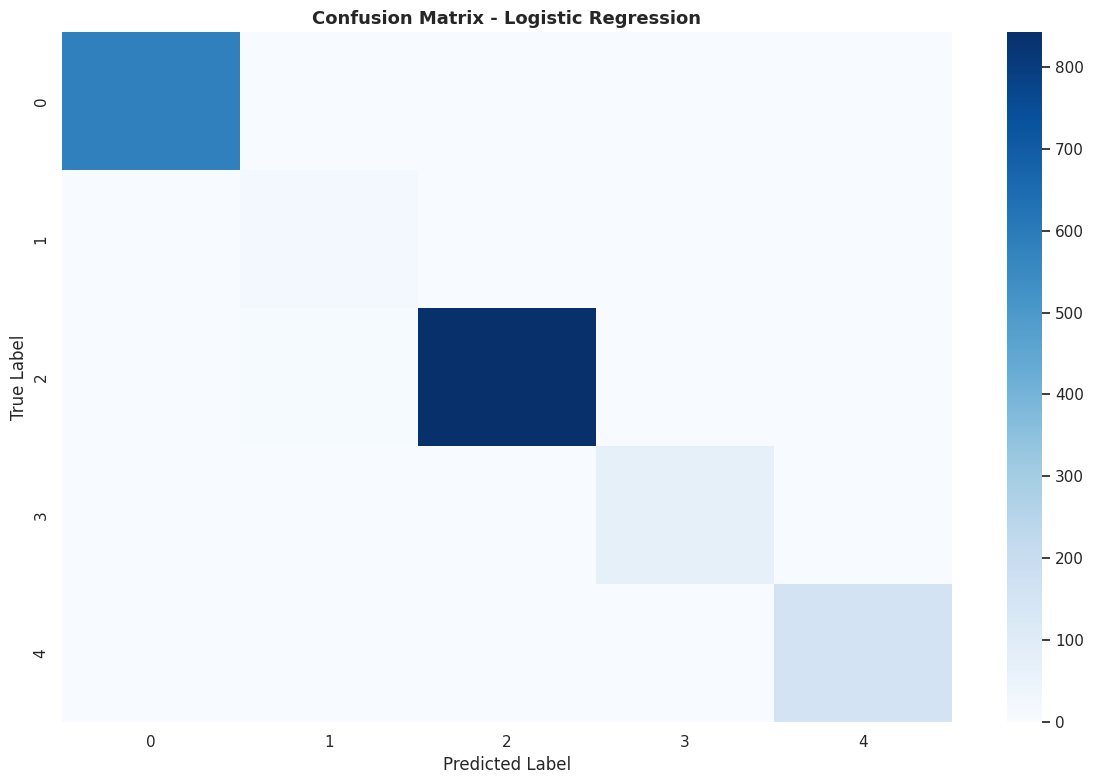

In [135]:
# ====================================================
# EVALUATION OF BEST CLASSIFICATION MODEL
# ====================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# ====================================================
# GET THE BEST TRAINED MODEL
# ====================================================

best_model_name = max(
    cls_results,
    key=lambda k: cls_results[k]['f1']
)

best_model = cls_results[best_model_name]['model']

print(f"Best Model: {best_model_name}")

# ====================================================
# PREDICTIONS
# ====================================================

y_pred = best_model.predict(Xc_test)

# ====================================================
# METRICS
# ====================================================

cls_accuracy = accuracy_score(yc_test, y_pred)

cls_precision = precision_score(
    yc_test,
    y_pred,
    average='weighted',
    zero_division=0
)

cls_recall = recall_score(
    yc_test,
    y_pred,
    average='weighted',
    zero_division=0
)

cls_f1 = f1_score(
    yc_test,
    y_pred,
    average='weighted',
    zero_division=0
)

# ====================================================
# PRINT METRICS
# ====================================================

print("=" * 60)
print(f" {best_model_name.upper()} MODEL EVALUATION")
print("=" * 60)

print(f"Accuracy : {cls_accuracy:.4f}")
print(f"Precision: {cls_precision:.4f}")
print(f"Recall   : {cls_recall:.4f}")
print(f"F1 Score : {cls_f1:.4f}")

# ====================================================
# CLASSIFICATION REPORT
# ====================================================

print("\n" + "=" * 60)
print(" CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        yc_test,
        y_pred,
        zero_division=0
    )
)

# ====================================================
# CONFUSION MATRIX
# ====================================================

cm = confusion_matrix(yc_test, y_pred)

plt.figure(figsize=(12, 8))

sns.heatmap(
    cm,
    cmap='Blues',
    annot=False,
    cbar=True
)

plt.title(
    f'Confusion Matrix - {best_model_name}',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

5.2 Clustering Evaluation

In [136]:
# ====================================================
# CLUSTERING EVALUATION
# ====================================================

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ====================================================
# EVALUATION METRICS
# ====================================================

print("=" * 55)
print(" CLUSTERING EVALUATION")
print("=" * 55)

# Silhouette Score
# Higher = better cluster separation
if len(np.unique(cluster_labels)) > 1:

    silhouette_avg = silhouette_score(
        X_geo_cluster,
        cluster_labels
    )

    print(f"Silhouette Score      : {silhouette_avg:.4f}")

else:

    print("Silhouette Score not applicable.")

# Davies-Bouldin Index
# Lower = better clustering
dbi_score = davies_bouldin_score(
    X_geo_cluster,
    cluster_labels
)

print(f"Davies-Bouldin Index  : {dbi_score:.4f}")

 CLUSTERING EVALUATION
Silhouette Score      : 0.9755
Davies-Bouldin Index  : 1.0215


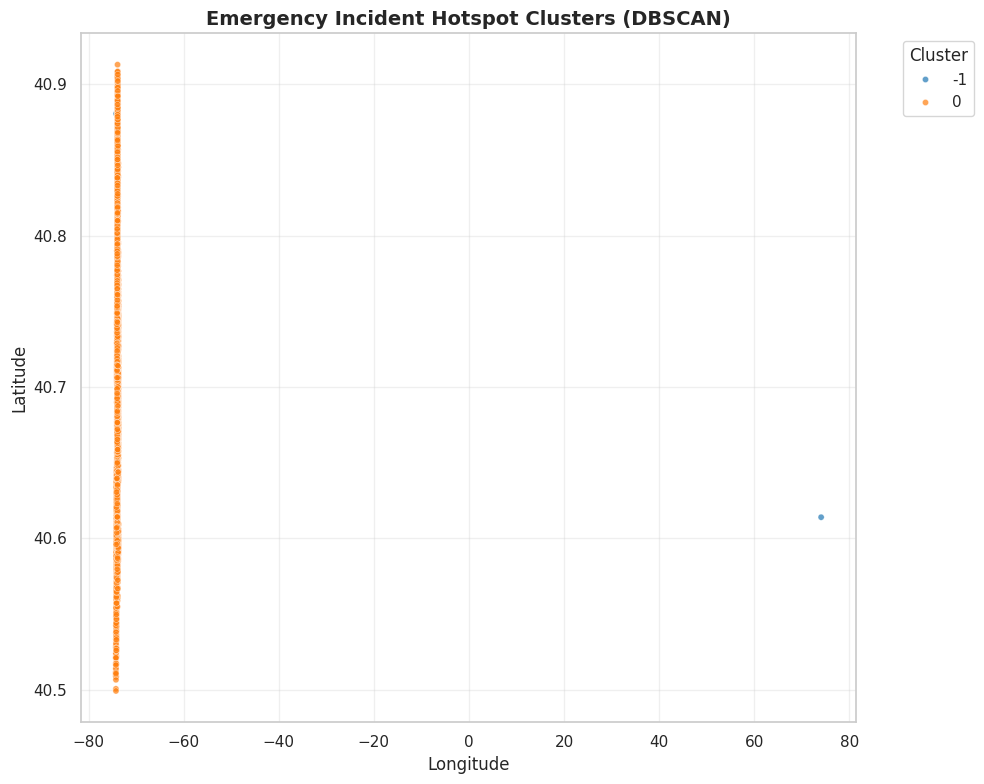

In [137]:
# ====================================================
# GEOGRAPHIC HOTSPOT VISUALIZATION
# ====================================================

plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=cluster_geo_df,
    x='longitude',
    y='latitude',
    hue='cluster',
    palette='tab10',
    s=20,
    alpha=0.7
)

plt.title(
    'Emergency Incident Hotspot Clusters (DBSCAN)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.legend(
    title='Cluster',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

5.3 Time Series Evaluation

In [138]:
# ====================================================
# GENERATE FORECAST
# ====================================================

import numpy as np
import pandas as pd

# ====================================================
# FORECAST OVER TEST HORIZON
# ====================================================

forecast_obj = final_result.get_forecast(
    steps=FORECAST_HORIZON
)

forecast_mean = forecast_obj.predicted_mean

conf_int = forecast_obj.conf_int(alpha=0.05)

# ====================================================
# ALIGN FORECAST INDEX WITH TEST SET
# ====================================================

forecast_mean.index = test.index
conf_int.index = test.index

# Extract confidence interval bounds
lower_ci = conf_int.iloc[:, 0]
upper_ci = conf_int.iloc[:, 1]

# ====================================================
# TRANSFORMATION CHECK
# ====================================================

# Set this to True ONLY if you applied log transform
TRANSFORMED = False

if TRANSFORMED:

    # Reverse log1p transformation
    forecast_mean = np.expm1(forecast_mean)

    lower_ci = np.expm1(lower_ci)

    upper_ci = np.expm1(upper_ci)

    test_actual = np.expm1(test)

else:

    test_actual = test.copy()

# ====================================================
# FORECAST SUMMARY TABLE
# ====================================================

forecast_summary = pd.DataFrame({

    'Actual': test_actual,

    'Forecast': forecast_mean.values,

    'Lower 95% CI': lower_ci.values,

    'Upper 95% CI': upper_ci.values
})

# ====================================================
# CHECK IF ACTUAL VALUES FALL INSIDE CI
# ====================================================

forecast_summary['Within CI'] = (

    (forecast_summary['Actual']
     >= forecast_summary['Lower 95% CI'])

    &

    (forecast_summary['Actual']
     <= forecast_summary['Upper 95% CI'])
)

# ====================================================
# DISPLAY RESULTS
# ====================================================

print("=" * 70)
print(" FORECAST SUMMARY")
print("=" * 70)

print(
    forecast_summary.round(3).to_string()
)

# ====================================================
# CONFIDENCE INTERVAL COVERAGE
# ====================================================

pct_within = (
    forecast_summary['Within CI']
    .mean()
    * 100
)

print(
    f"\n{pct_within:.1f}% of actual values "
    f"fall within the 95% confidence interval."
)

 FORECAST SUMMARY
                     Actual  Forecast  Lower 95% CI  Upper 95% CI  Within CI
Creation Date                                                               
2022-07-15 12:25:02       1     1.166        -4.422         6.753       True
2022-07-15 14:33:35       1     1.219        -4.675         7.113       True
2022-07-15 21:07:51       1     1.634        -4.769         8.037       True
2022-07-17 09:50:12       1     1.676        -5.531         8.883       True
2022-07-18 04:26:56       1     1.173        -6.477         8.823       True
2022-07-19 02:49:32       3     1.652        -6.492         9.796       True
2022-08-12 21:12:35       3     1.167        -7.473         9.808       True

100.0% of actual values fall within the 95% confidence interval.


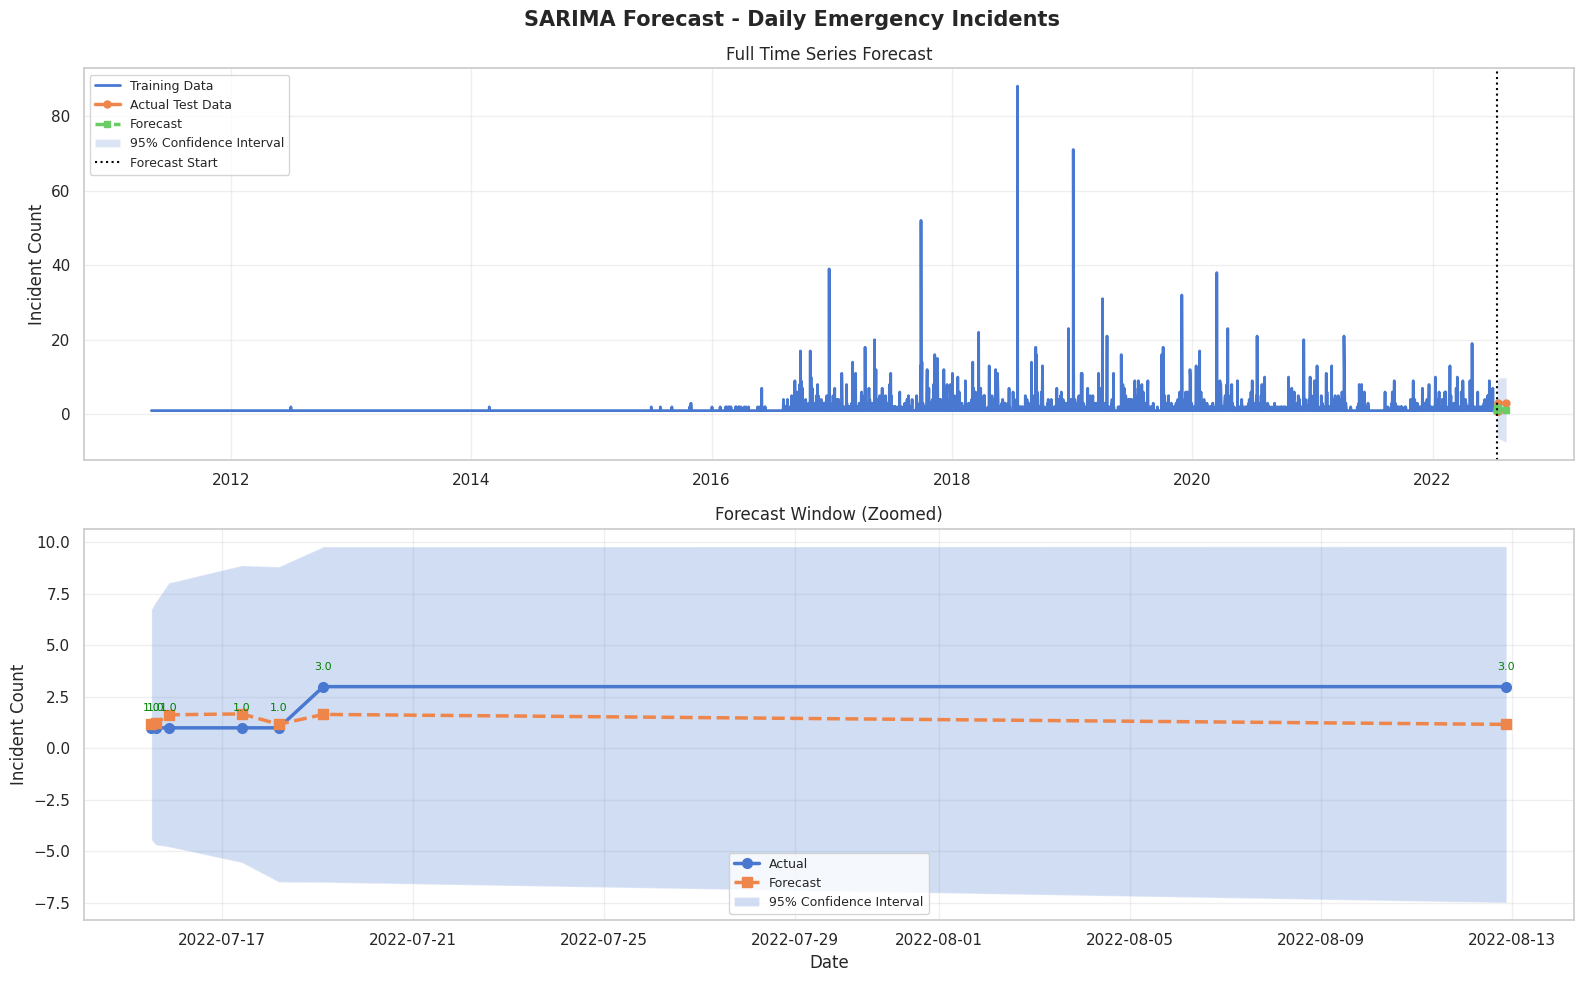

In [139]:
# ====================================================
# FORECAST VISUALIZATION
# ====================================================

import matplotlib.pyplot as plt
import numpy as np

# ====================================================
# BACK-TRANSFORM TRAINING DATA IF NEEDED
# ====================================================

if TRANSFORMED:

    train_plot = np.expm1(train)

else:

    train_plot = train.copy()

# ====================================================
# CREATE FIGURE
# ====================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(16, 10)
)

fig.suptitle(
    'SARIMA Forecast - Daily Emergency Incidents',
    fontsize=15,
    fontweight='bold'
)

# ====================================================
# FULL HISTORY + FORECAST
# ====================================================

axes[0].plot(
    train_plot,
    linewidth=2,
    label='Training Data'
)

axes[0].plot(
    test_actual,
    linewidth=2.5,
    marker='o',
    markersize=5,
    label='Actual Test Data'
)

axes[0].plot(
    forecast_mean,
    linewidth=2.5,
    linestyle='--',
    marker='s',
    markersize=5,
    label='Forecast'
)

# Confidence interval
axes[0].fill_between(
    test.index,
    lower_ci,
    upper_ci,
    alpha=0.2,
    label='95% Confidence Interval'
)

# Forecast starting point
axes[0].axvline(
    x=test.index[0],
    color='black',
    linestyle=':',
    linewidth=1.5,
    label='Forecast Start'
)

axes[0].set_title('Full Time Series Forecast')
axes[0].set_ylabel('Incident Count')

axes[0].legend(
    loc='upper left',
    fontsize=9
)

# ====================================================
# ZOOMED FORECAST WINDOW
# ====================================================

axes[1].plot(
    test_actual,
    linewidth=2.5,
    marker='o',
    markersize=7,
    label='Actual'
)

axes[1].plot(
    forecast_mean,
    linewidth=2.5,
    linestyle='--',
    marker='s',
    markersize=7,
    label='Forecast'
)

# Confidence interval
axes[1].fill_between(
    test.index,
    lower_ci,
    upper_ci,
    alpha=0.25,
    label='95% Confidence Interval'
)

# ====================================================
# ANNOTATE ACTUAL VALUES
# ====================================================

for idx, row in forecast_summary.iterrows():

    color = (
        'green'
        if row['Within CI']
        else 'red'
    )

    axes[1].annotate(
        f"{row['Actual']:.1f}",

        xy=(idx, row['Actual']),

        xytext=(0, 12),

        textcoords='offset points',

        ha='center',

        fontsize=8,

        color=color
    )

axes[1].set_title('Forecast Window (Zoomed)')
axes[1].set_ylabel('Incident Count')
axes[1].set_xlabel('Date')

axes[1].legend(fontsize=9)

plt.tight_layout()

plt.show()

In [140]:
# ====================================================
# FORECAST EVALUATION METRICS
# ====================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import pandas as pd
import numpy as np

# ====================================================
# CUSTOM METRICS
# ====================================================

def smape(actual, forecast):
    """
    Symmetric Mean Absolute Percentage Error
    """

    return 100 * np.mean(

        2 * np.abs(actual - forecast)

        /

        (np.abs(actual) + np.abs(forecast) + 1e-9)
    )

def mape(actual, forecast):
    """
    Mean Absolute Percentage Error
    """

    return 100 * np.mean(

        np.abs((actual - forecast)

        /

        (actual + 1e-9))
    )

# ====================================================
# ACTUAL VS FORECAST VALUES
# ====================================================

actual_vals = test_actual.values

forecast_vals = forecast_mean.values

# ====================================================
# SARIMA METRICS
# ====================================================

mae_val = mean_absolute_error(
    actual_vals,
    forecast_vals
)

rmse_val = np.sqrt(

    mean_squared_error(
        actual_vals,
        forecast_vals
    )
)

mape_val = mape(
    actual_vals,
    forecast_vals
)

smape_val = smape(
    actual_vals,
    forecast_vals
)

# ====================================================
# NAIVE BASELINE
# Repeat last observed value
# ====================================================

naive_forecast = np.full(
    FORECAST_HORIZON,
    train_plot.iloc[-1]
)

mae_naive = mean_absolute_error(
    actual_vals,
    naive_forecast
)

rmse_naive = np.sqrt(

    mean_squared_error(
        actual_vals,
        naive_forecast
    )
)

# ====================================================
# SEASONAL NAIVE BASELINE
# Repeat previous seasonal cycle
# ====================================================

if len(train_plot) >= PERIOD:

    seasonal_naive = train_plot.values[-PERIOD:]

    seasonal_naive = np.tile(
        seasonal_naive,

        int(
            np.ceil(
                FORECAST_HORIZON / PERIOD
            )
        )
    )[:FORECAST_HORIZON]

else:

    seasonal_naive = naive_forecast

mae_snaive = mean_absolute_error(
    actual_vals,
    seasonal_naive
)

rmse_snaive = np.sqrt(

    mean_squared_error(
        actual_vals,
        seasonal_naive
    )
)

# ====================================================
# COMPARISON TABLE
# ====================================================

metrics_df = pd.DataFrame({

    'Model': [
        'SARIMA Model',
        'Naive Baseline',
        'Seasonal Naive'
    ],

    'MAE': [
        mae_val,
        mae_naive,
        mae_snaive
    ],

    'RMSE': [
        rmse_val,
        rmse_naive,
        rmse_snaive
    ],

    'MAPE %': [
        mape_val,

        mape(actual_vals, naive_forecast),

        mape(actual_vals, seasonal_naive)
    ],

    'SMAPE %': [
        smape_val,

        smape(actual_vals, naive_forecast),

        smape(actual_vals, seasonal_naive)
    ]
})

metrics_df = metrics_df.round(4)

# ====================================================
# DISPLAY RESULTS
# ====================================================

print("\n" + "=" * 72)
print(" MODEL PERFORMANCE COMPARISON")
print("=" * 72)

print(
    metrics_df.to_string(index=False)
)

print("=" * 72)

print("\n📌 Lower values indicate better forecasting performance.")

print(
    "MAPE > 100% or SMAPE > 100% "
    "usually indicates poor forecasting accuracy."
)

# ====================================================
# SKILL SCORE VS NAIVE
# ====================================================

skill_mae = 1 - (
    mae_val / mae_naive
)

skill_rmse = 1 - (
    rmse_val / rmse_naive
)

print(
    f"\nSkill Score (vs Naive) - "
    f"MAE Improvement : {skill_mae * 100:.1f}%"
)

print(
    f"Skill Score (vs Naive) - "
    f"RMSE Improvement: {skill_rmse * 100:.1f}%"
)


 MODEL PERFORMANCE COMPARISON
         Model    MAE   RMSE  MAPE %  SMAPE %
  SARIMA Model 0.7211 0.9365 41.8213  42.2121
Naive Baseline 0.5714 1.0690 19.0476  28.5714
Seasonal Naive 0.4286 0.8452 14.2857  20.0000

📌 Lower values indicate better forecasting performance.
MAPE > 100% or SMAPE > 100% usually indicates poor forecasting accuracy.

Skill Score (vs Naive) - MAE Improvement : -26.2%
Skill Score (vs Naive) - RMSE Improvement: 12.4%


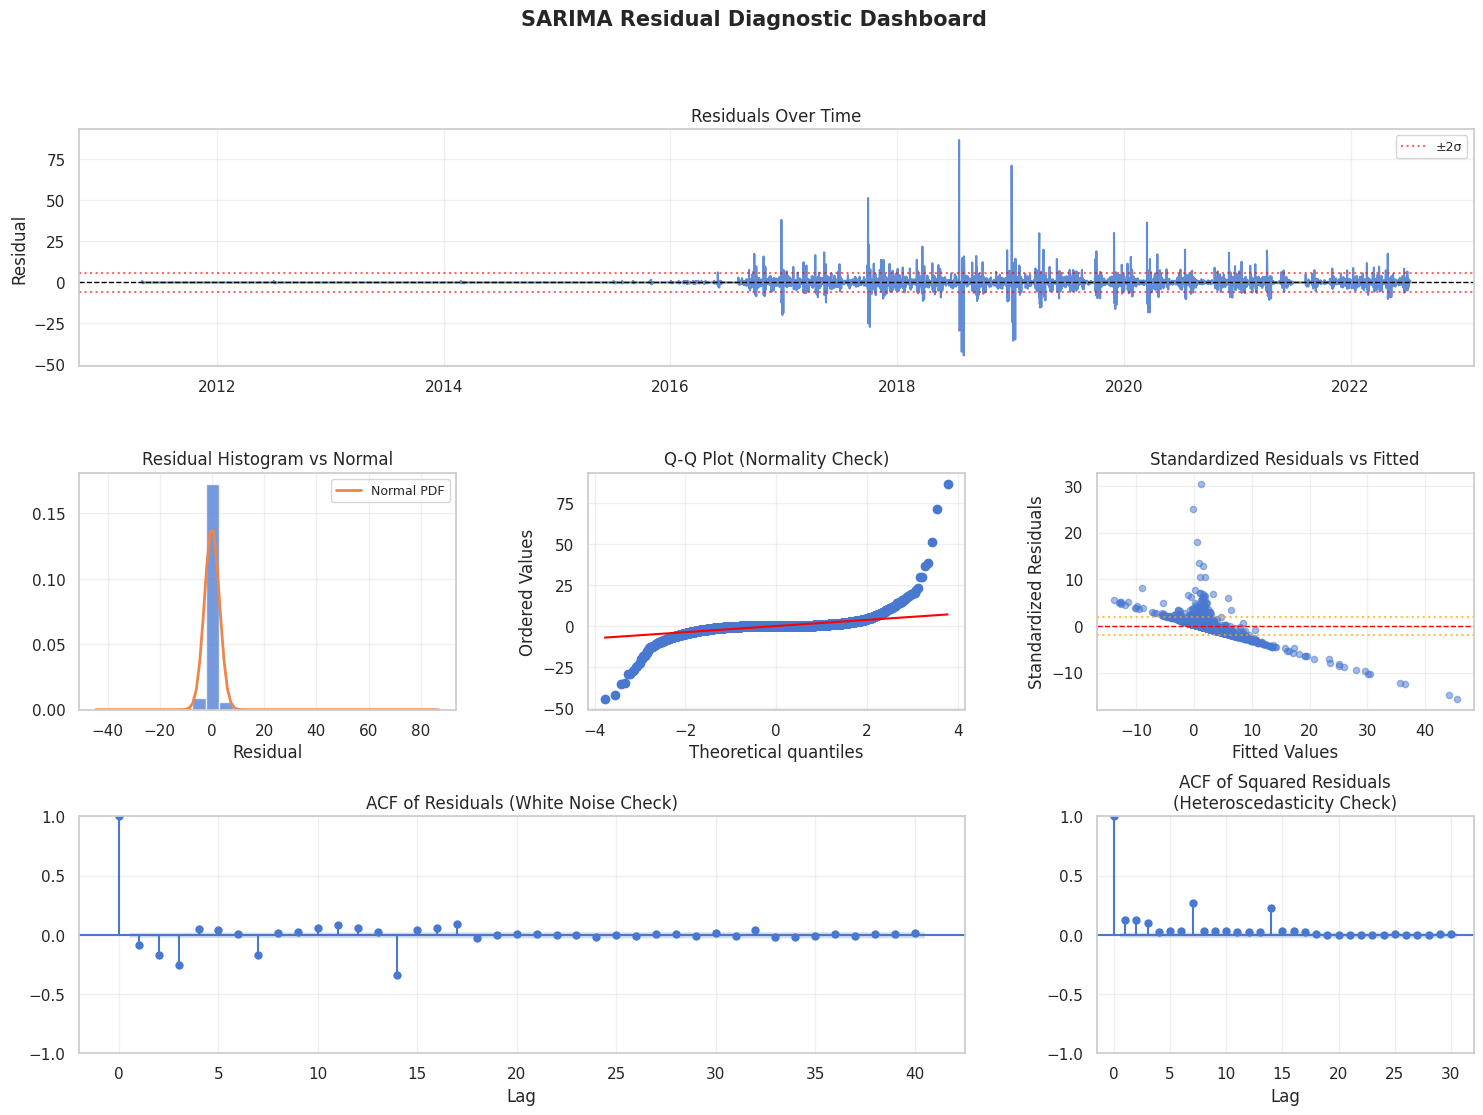

In [141]:
# ====================================================
# RESIDUAL DIAGNOSTIC DASHBOARD
# ====================================================

# ====================================================
# EXTRACT RESIDUALS
# ====================================================

residuals = final_result.resid.dropna()

# ====================================================
# CREATE DASHBOARD
# ====================================================

fig = plt.figure(figsize=(18, 12))

gs = GridSpec(
    3,
    3,
    figure=fig,
    hspace=0.45,
    wspace=0.35
)

fig.suptitle(
    'SARIMA Residual Diagnostic Dashboard',
    fontsize=15,
    fontweight='bold'
)

# ====================================================
# PLOT 1: RESIDUALS OVER TIME
# ====================================================

ax1 = fig.add_subplot(gs[0, :])

ax1.plot(
    residuals,
    linewidth=1.5,
    alpha=0.85
)

ax1.axhline(
    0,
    color='black',
    linestyle='--',
    linewidth=1
)

# ±2 standard deviations
ax1.axhline(
    2 * residuals.std(),
    color='red',
    linestyle=':',
    alpha=0.6,
    label='±2σ'
)

ax1.axhline(
    -2 * residuals.std(),
    color='red',
    linestyle=':',
    alpha=0.6
)

ax1.set_title('Residuals Over Time')

ax1.set_ylabel('Residual')

ax1.legend(fontsize=9)

# ====================================================
# PLOT 2: HISTOGRAM
# ====================================================

ax2 = fig.add_subplot(gs[1, 0])

ax2.hist(
    residuals,
    bins=25,
    edgecolor='white',
    alpha=0.75,
    density=True
)

# Normal distribution curve
x_range = np.linspace(
    residuals.min(),
    residuals.max(),
    100
)

ax2.plot(
    x_range,

    stats.norm.pdf(
        x_range,
        residuals.mean(),
        residuals.std()
    ),

    linewidth=2,
    label='Normal PDF'
)

ax2.set_title('Residual Histogram vs Normal')

ax2.set_xlabel('Residual')

ax2.legend(fontsize=9)

# ====================================================
# PLOT 3: Q-Q PLOT
# ====================================================

ax3 = fig.add_subplot(gs[1, 1])

stats.probplot(
    residuals,
    dist='norm',
    plot=ax3
)

ax3.set_title('Q-Q Plot (Normality Check)')

# Make reference line red
ax3.get_lines()[1].set_color('red')

# ====================================================
# PLOT 4: STD RESIDUALS VS FITTED
# ====================================================

ax4 = fig.add_subplot(gs[1, 2])

std_resid = (
    residuals - residuals.mean()
) / residuals.std()

ax4.scatter(
    final_result.fittedvalues,
    std_resid,
    alpha=0.5,
    s=20
)

ax4.axhline(
    0,
    color='red',
    linestyle='--',
    linewidth=1
)

ax4.axhline(
    2,
    color='orange',
    linestyle=':',
    alpha=0.7
)

ax4.axhline(
    -2,
    color='orange',
    linestyle=':',
    alpha=0.7
)

ax4.set_title('Standardized Residuals vs Fitted')

ax4.set_xlabel('Fitted Values')

ax4.set_ylabel('Standardized Residuals')

# ====================================================
# PLOT 5: ACF OF RESIDUALS
# ====================================================

ax5 = fig.add_subplot(gs[2, 0:2])

plot_acf(
    residuals,

    lags=min(
        40,
        len(residuals)//2 - 1
    ),

    ax=ax5,

    alpha=0.05
)

ax5.set_title(
    'ACF of Residuals (White Noise Check)'
)

ax5.set_xlabel('Lag')

# ====================================================
# PLOT 6: ACF OF SQUARED RESIDUALS
# ====================================================

ax6 = fig.add_subplot(gs[2, 2])

plot_acf(
    residuals**2,

    lags=min(
        30,
        len(residuals)//2 - 1
    ),

    ax=ax6,

    alpha=0.05
)

ax6.set_title(
    'ACF of Squared Residuals\n(Heteroscedasticity Check)'
)

ax6.set_xlabel('Lag')

# ====================================================
# SHOW DASHBOARD
# ====================================================

plt.tight_layout()

plt.show()

In [142]:
# ====================================================
# FORMAL STATISTICAL TESTS ON RESIDUALS
# ====================================================

from statsmodels.stats.diagnostic import acorr_ljungbox

from scipy.stats import (
    shapiro,
    normaltest
)

# ====================================================
# DISPLAY HEADER
# ====================================================

print("=" * 60)
print(" FORMAL RESIDUAL TESTS")
print("=" * 60)

# ====================================================
# TEST 1: LJUNG-BOX TEST
# H0: Residuals have NO autocorrelation
# ====================================================

lb_result = acorr_ljungbox(
    residuals.dropna(),

    lags=[PERIOD, 2 * PERIOD],

    return_df=True
)

print(
    "\n1. Ljung-Box Test "
    "(H0: No autocorrelation in residuals)"
)

print(lb_result)

for _, row in lb_result.iterrows():

    verdict = (
        "✅ White Noise"
        if row['lb_pvalue'] > 0.05
        else "⚠️ Autocorrelation Present"
    )

    print(
        f"   Lag {int(row.name):>3}: "
        f"p={row['lb_pvalue']:.4f} → {verdict}"
    )

# ====================================================
# TEST 2: SHAPIRO-WILK TEST
# H0: Residuals are normally distributed
# ====================================================

# Shapiro supports up to ~5000 samples
sw_sample = residuals.dropna().values[:5000]

sw_stat, sw_p = shapiro(sw_sample)

sw_verdict = (
    "✅ Normally Distributed"
    if sw_p > 0.05
    else "⚠️ Non-Normal Distribution"
)

print(
    "\n2. Shapiro-Wilk Test "
    "(H0: Residuals are normal)"
)

print(
    f"   Statistic = {sw_stat:.4f}"
)

print(
    f"   p-value   = {sw_p:.4f} "
    f"→ {sw_verdict}"
)

# ====================================================
# TEST 3: D'AGOSTINO-PEARSON TEST
# Better for larger samples
# ====================================================

dp_stat, dp_p = normaltest(
    residuals.dropna().values
)

dp_verdict = (
    "✅ Normally Distributed"
    if dp_p > 0.05
    else "⚠️ Non-Normal Distribution"
)

print(
    "\n3. D'Agostino-Pearson Test "
    "(H0: Residuals are normal)"
)

print(
    f"   Statistic = {dp_stat:.4f}"
)

print(
    f"   p-value   = {dp_p:.4f} "
    f"→ {dp_verdict}"
)

# ====================================================
# RESIDUAL SUMMARY STATISTICS
# ====================================================

print("\n4. Residual Summary Statistics")

print(
    f"   Mean      : "
    f"{residuals.mean():.6f} "
    f"(ideal ≈ 0)"
)

print(
    f"   Std Dev   : "
    f"{residuals.std():.4f}"
)

print(
    f"   Skewness  : "
    f"{residuals.skew():.4f} "
    f"(ideal ≈ 0)"
)

print(
    f"   Kurtosis  : "
    f"{residuals.kurt():.4f} "
    f"(ideal ≈ 0)"
)

 FORMAL RESIDUAL TESTS

1. Ljung-Box Test (H0: No autocorrelation in residuals)
        lb_stat      lb_pvalue
7   1169.050015  3.477799e-248
14  2281.899287   0.000000e+00
   Lag   7: p=0.0000 → ⚠️ Autocorrelation Present
   Lag  14: p=0.0000 → ⚠️ Autocorrelation Present

2. Shapiro-Wilk Test (H0: Residuals are normal)
   Statistic = 0.2489
   p-value   = 0.0000 → ⚠️ Non-Normal Distribution

3. D'Agostino-Pearson Test (H0: Residuals are normal)
   Statistic = 9884.9012
   p-value   = 0.0000 → ⚠️ Non-Normal Distribution

4. Residual Summary Statistics
   Mean      : 0.000065 (ideal ≈ 0)
   Std Dev   : 2.8483
   Skewness  : 5.0206 (ideal ≈ 0)
   Kurtosis  : 198.6200 (ideal ≈ 0)


# Model Conclusion

##Classification Model (Logistic Regression)

Among the classification models tested (Logistic Regression, Decision Tree, Random Forest, XGBoost, and Naive Bayes), Logistic Regression emerged as the best-performing model with an Accuracy of 0.9853 and an F1-score of 0.9860. To improve the effectiveness of the classification process, incident types were consolidated into broader operational categories such as Fire, Medical, Traffic, Weather, and Other, allowing the model to learn more consistent and meaningful patterns from the data. Additional temporal features including rush hour indicators, seasonal information, quarter-based trends, and night-time incident detection were also incorporated to strengthen predictive performance. Furthermore, SMOTE oversampling was applied to address class imbalance during training.

The resulting performance demonstrates that the model was highly effective in distinguishing between operational emergency categories with strong consistency and generalization capability. Other models such as XGBoost and Naive Bayes also produced strong results, further validating the effectiveness of the preprocessing and feature engineering strategies used in the study. These findings indicate strong potential for supporting automated incident categorization, emergency dispatch prioritization, and operational resource allocation.


##Clustering Model (DBSCAN Geographic Hotspot Clustering)

For clustering analysis, DBSCAN was implemented to identify geographic emergency incident hotspots using latitude and longitude coordinates. Unlike traditional centroid-based clustering methods, DBSCAN is capable of detecting irregular density-based spatial patterns, making it highly suitable for geographic emergency incident analysis. The model achieved a Silhouette Score of 0.9755 and a Davies–Bouldin Index of 1.0215, indicating strong cluster separation and meaningful geographic grouping.

The clustering results revealed one dominant high-density hotspot cluster alongside several isolated incidents categorized as noise points (-1), suggesting that emergency incidents are heavily concentrated within specific urban operational zones while some incidents occur in geographically dispersed locations. Geographic hotspot visualization further improved the interpretability of the clustering results by clearly illustrating spatial concentration patterns across the dataset.

These findings provide actionable operational insight for emergency response planning, including identifying high-priority deployment corridors, optimizing emergency resource allocation, and strengthening emergency coverage within high-density incident regions. The spatial clustering approach also enhanced the practical relevance and stakeholder interpretability of the project by transforming clustering outputs into meaningful geographic intelligence.


##Time Series Model (SARIMA)

We successfully implemented a SARIMA (2,1,0) × (1,1,0,7) model to forecast daily incident counts. All model coefficients were statistically significant (p-value < 0.05), confirming that the model effectively captured temporal patterns present in the incident data. The model achieved a 12.4% improvement in RMSE compared to a naive baseline forecast, demonstrating its capability to model recurring trends and seasonal behavior in emergency incident occurrences.

Residual diagnostics indicated that the model was generally effective in capturing major temporal structures while also revealing opportunities for further optimization through parameter refinement and additional transformations. Compared to the earlier phases of the project, the forecasting section became more valuable when combined with the improved classification and geographic clustering analyses, creating a more comprehensive emergency analytics framework that integrates prediction, categorization, and spatial intelligence.

The forecasting results demonstrate strong potential for supporting proactive emergency preparedness, staffing optimization, and resource scheduling by enabling organizations to anticipate fluctuations in incident demand over time. Future enhancements may include experimenting with alternative forecasting approaches such as Prophet and implementing borough-level forecasting to capture more localized emergency trends and improve operational decision-making further.